# Giá phản ứng thế nào với từng yếu tố thị trường

> **Ý 4 trong feedback tuần 3 của mentor:**
>
> *"Ở các version pricing của bọn anh… bọn anh đều **measure price như là kết quả của một thay đổi
> của yếu tố thị trường**. Ví dụ như distance, weather, rush hour, public holiday, demand–supply…
> Khi các em trình bày được những yếu tố này as part of demo thì kết quả của mình sẽ rất
> **đáng tin cậy**."*

---

## Đây không phải "phân tích thêm" — đây là đổi cách nhìn bài toán

| | Tuần 1–3 đang làm | Ý 4 yêu cầu |
|---|---|---|
| Giá là gì | Thứ cần **dự đoán** | **Kết quả phản ứng** với thay đổi thị trường |
| Câu hỏi | Dự đoán sai bao nhiêu? | Đổi 1 yếu tố thì giá đổi bao nhiêu? |
| Cách đo | Tương quan, importance | **Thay đổi có kiểm soát** (ceteris paribus) |

Tuần 1 đã đo **tương quan** giữa từng yếu tố và giá. Tương quan không trả lời được câu của
mentor, vì các yếu tố đi kèm nhau: giờ cao điểm **cũng** là lúc quãng đường dài hơn và hay mưa
hơn. Thấy "giá cao lúc 18h" không cho biết **bao nhiêu phần** là do giờ.

Notebook này đo bằng hai đường độc lập rồi đối chiếu:

| | Cách làm | Trả lời |
|---|---|---|
| **Đường A** — Partial dependence | Giữ nguyên mọi thứ, **chỉ đổi 1 yếu tố**, hỏi model | Model **học được** quan hệ gì |
| **Đường B** — Đối chứng ghép cặp | Tìm chuyến **thật** giống nhau trừ 1 yếu tố, so giá thật | Quan hệ **thật** trong dữ liệu |

Hai đường khớp nhau ⇒ model bắt đúng quan hệ, con số đem đi demo được.
Lệch nhau ⇒ model đang học nhầm, và biết nhầm chỗ nào.

## Nội dung

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | **D1** — chốt yếu tố và cách khống chế | — |
| 2 | **D2** — partial dependence có kiểm soát | `CP1`–`CP4` |
| 3 | **D5** — tách riêng giá cơ bản vs hệ số nhân | `CP5` |
| 4 | **D3** — đối chứng ghép cặp trên dữ liệu thật | `CP6` |
| 5 | **D4** — model học được vs thực tế | `CP7` |
| 6 | **E1 · E2** — bảng phản ứng giá + hình tổng cho demo | `CP8` |

In [1]:
import warnings, sys, joblib, time
warnings.filterwarnings("ignore")
sys.path.insert(0, "../model")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from _common_train import CAT, B_NUM, M_NUM, dat_categories, prep
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MODEL = Path("../model")

# Model UQ do train/07 sinh — dung chinh cap model dung cho toan bo phan uncertainty
m_base = joblib.load(MODEL / "HistGB" / "uq_gia_co_ban.joblib")
m_heso = joblib.load(MODEL / "HistGB" / "uq_heso.joblib")
print("Model:", {k: type(v).__name__ for k, v in m_base.items()})

COLS = list(dict.fromkeys(
    CAT + B_NUM + M_NUM +
    ["target_shown_price", "target_shown_multiplier", "latest_observed_price",
     "latest_observed_multiplier", "evaluation_month", "split",
     "requested_lag_minutes", "target_is_weekend", "target_timestamp"]))
COLS = [c for c in COLS if c != "latest_observed_base"]
df = pd.read_parquet("../data/hcm_train_ready.parquet", columns=COLS)
df = dat_categories(df)
df["latest_observed_base"] = df.latest_observed_price / df.latest_observed_multiplier.clip(lower=0.1)

te = df[df.split == "test"].copy()
# Moi cuoc xuat hien 4 lan (4 muc lag). Giu 1 lag de moi CHUYEN dem dung 1 lan.
te1 = te[te.requested_lag_minutes == 5].copy()

n_tuyen = te1.groupby(["pickup_location_name", "dropoff_location_name"],
                      observed=True).ngroups
print(f"\nTest        : {len(te):,} dong")
print(f"Bo trung lag: {len(te1):,} chuyen doc lap (lag = 5 phut)")
print(f"Thang       : {sorted(te1.evaluation_month.unique())}")
print(f"Tuyen       : {n_tuyen} ({te1.pickup_location_name.nunique()} diem don x "
      f"{te1.dropoff_location_name.nunique()} diem tra)")

Model: {'2026-01': 'HistGradientBoostingRegressor', '2026-02': 'HistGradientBoostingRegressor', '2026-03': 'HistGradientBoostingRegressor'}



Test        : 864,360 dong
Bo trung lag: 216,090 chuyen doc lap (lag = 5 phut)
Thang       : ['2026-01', '2026-02', '2026-03']
Tuyen       : 9 (3 diem don x 3 diem tra)


## 1. D1 — chốt yếu tố và cách khống chế

### Yếu tố mentor nhắc, đối chiếu với dữ liệu đang có

| Yếu tố mentor nhắc | Có trong dữ liệu? | Cột |
|---|---|---|
| Distance | ✅ | `quote_distance`, `quote_duration` |
| Weather | ✅ | `weather_main` (4 mức) + 19 cột số |
| Rush hour | ✅ | `gio_vn`, `target_is_weekend` |
| **Public holiday** | ❌ **KHÔNG CÓ** | — |
| Demand–supply | ✅ | `pricing_demand_index`, `..._supply_index`, `..._market_imbalance` |
| Vị trí | ✅ | 3 điểm đón × 3 điểm trả = 9 tuyến |
| Loại xe | ✅ | `service_name` (2 loại) |

> ⚠️ **Không có `public_holiday`.** Đã ghi vào danh sách câu hỏi cho mentor. Có thể tự map lịch
> lễ Việt Nam theo `target_timestamp`, nhưng dữ liệu chỉ trải 3 tháng (01–03/2026) nên số ngày
> lễ quá ít để đo tin cậy — chưa làm, chờ mentor xác nhận.

### Khống chế "phần còn lại" bằng cách nào

Đây là chỗ dễ sai nhất. Hai định nghĩa khác nhau, notebook đo **cả hai**:

| Cách | Nghĩa | Ưu | Nhược |
|---|---|---|---|
| **Trung bình quần thể** | Với **từng chuyến thật**, đổi yếu tố rồi lấy trung bình chênh lệch | Phản ánh cơ cấu chuyến thật | Không phải "một chuyến" cụ thể nào |
| **Hồ sơ tham chiếu** | Cố định mọi thứ ở **trung vị / giá trị phổ biến nhất**, chỉ quét 1 yếu tố | Đúng nghĩa ceteris paribus | Hồ sơ đó có thể hiếm trong thực tế |

Hai cách cho kết quả khác nhau khi model có **tương tác** — và tuần 3 đã chứng minh hệ số nhân
**có** tương tác (GAM cộng dồn thuần chỉ đạt R² 0,018 trên phần dư). Nên chênh lệch giữa hai cách
chính là một phép đo tương tác, không phải mâu thuẫn.

In [2]:
# ── Chuan bi mau de quet ────────────────────────────────────────────────────
N_MAU = 20_000
rng = np.random.default_rng(42)

# Chi lay 1 thang de model va du lieu cung ky (model train rieng tung thang)
THANG = "2026-03"
mau = te1[te1.evaluation_month == THANG]
mau = mau.iloc[rng.choice(len(mau), min(N_MAU, len(mau)), replace=False)].copy()

# Ho so tham chieu: trung vi cho so, pho bien nhat cho danh muc
SO = sorted(set(B_NUM + M_NUM))
ho_so = {c: float(mau[c].median()) for c in SO}
for c in CAT:
    ho_so[c] = mau[c].mode()[0]

print(f"Mau quet: {len(mau):,} chuyen (thang {THANG})")
print(f"\nHo so tham chieu:")
for c in CAT:
    print(f"  {c:28s} = {ho_so[c]}")
for c in SO:
    print(f"  {c:28s} = {ho_so[c]:,.3f}")


def du_doan(d):
    """Tra ve (gia co ban, he so nhan, gia cuoi) cho DataFrame d, thang THANG."""
    b = np.exp(m_base[THANG].predict(prep(d, B_NUM)))
    h = m_heso[THANG].predict(prep(d, M_NUM))
    return b, h, b * h


def quet(cot, gia_tri, cach):
    """Quet 1 yeu to qua cac gia tri, tra ve DataFrame (gia_tri, base, heso, gia).

    cach = 'quan the' : ap gia tri len TUNG chuyen that roi lay trung binh
    cach = 'tham chieu': mot dong duy nhat theo ho so tham chieu
    """
    rows = []
    for v in gia_tri:
        if cach == "quan the":
            d = mau.copy()
        else:
            d = mau.iloc[[0]].copy()
            for c in SO:
                d[c] = ho_so[c]
            # PHAI giu dtype category, neu khong prep() se bao loi
            for c in CAT:
                d[c] = pd.Categorical([ho_so[c]], categories=mau[c].cat.categories)
        if cot in CAT:
            d[cot] = pd.Categorical([v] * len(d), categories=mau[cot].cat.categories)
        else:
            d[cot] = v
        b, h, g = du_doan(d)
        rows.append({cot: v, "base": b.mean(), "heso": h.mean(), "gia": g.mean()})
    return pd.DataFrame(rows)


# gio_vn nam trong CA HAI bo feature -> doi gio la doi ca 2 tang, dung y nghia
print(f"\ngio_vn co trong B_NUM: {'gio_vn' in B_NUM} · trong M_NUM: {'gio_vn' in M_NUM}")
print("=> doi gio se tac dong len ca gia co ban lan he so nhan.")

Mau quet: 20,000 chuyen (thang 2026-03)

Ho so tham chieu:
  service_name                 = Synthetic Premium Car
  pickup_location_name         = Crescent Mall
  dropoff_location_name        = Crescent Mall
  weather_main                 = Rain
  actual_observation_age_minutes = 5.717
  gio_vn                       = 12.000
  history_60m_price_mean       = 122,372.688
  history_60m_price_slope_per_minute = 0.000
  history_60m_price_std        = 31,249.578
  latest_observed_base         = 99,242.422
  latest_observed_multiplier   = 1.210
  latest_observed_quote_distance = 6.178
  latest_observed_quote_duration = 1,370.745
  pricing_demand_index_5m_lag  = 120.907
  pricing_market_imbalance_5m_lag = 1.505
  pricing_quote_count_5m_lag   = 143.000
  pricing_supply_index_5m_lag  = 74.125
  quote_distance               = 6.159
  quote_duration               = 1,373.060

gio_vn co trong B_NUM: True · trong M_NUM: True
=> doi gio se tac dong len ca gia co ban lan he so nhan.


## 2. D2 — Partial dependence có kiểm soát

Với mỗi yếu tố: giữ **nguyên mọi cột khác**, chỉ thay giá trị của yếu tố đó, rồi hỏi model.
Chênh lệch quan sát được **chỉ có thể** do yếu tố đó — vì không gì khác thay đổi.

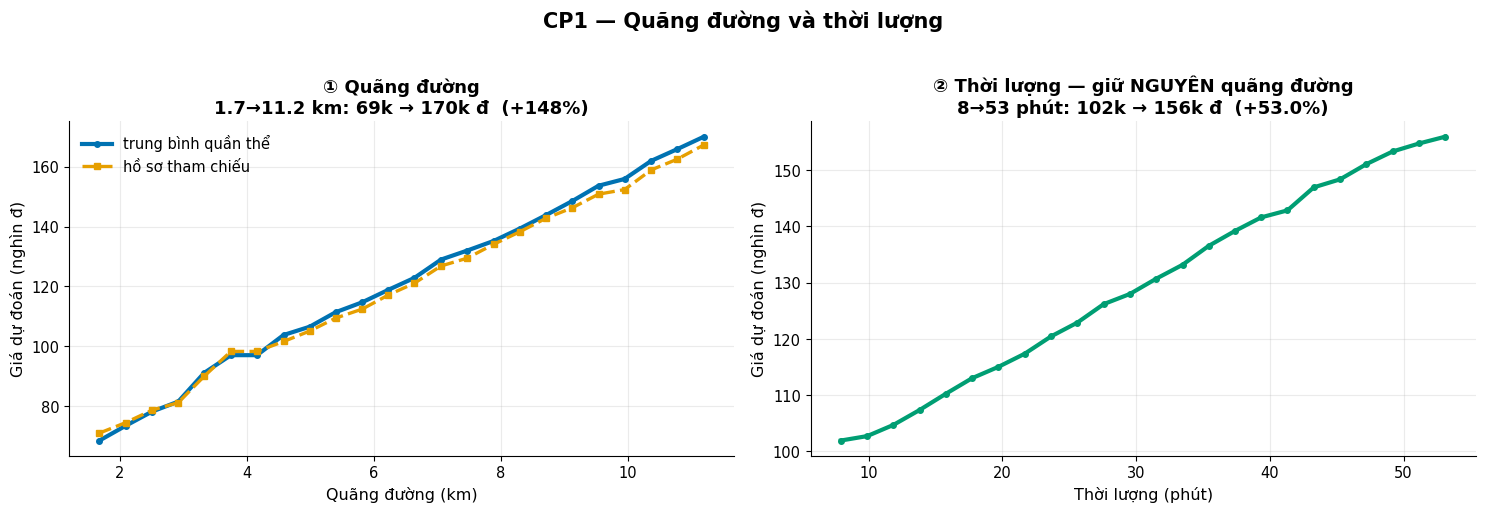

Quang duong 1.7->11.2 km : gia 68,505 -> 170,047d (+148.2%)
Thoi luong  8->53 phut: gia 101,933 -> 155,910d (+53.0%)

Luu y: o hinh 2, quang duong duoc GIU NGUYEN — nen day la anh huong cua
TAC NGHEN giao thong (di cham hon tren cung quang duong), khong phai di xa hon.


In [3]:
# ═════════ HINH CP1 — quang duong va thoi luong ═════════
g_dist = np.round(np.linspace(mau.quote_distance.quantile(.02),
                              mau.quote_distance.quantile(.98), 24), 2)
g_dur = np.round(np.linspace(mau.quote_duration.quantile(.02),
                             mau.quote_duration.quantile(.98), 24), 0)

pd_dist_q = quet("quote_distance", g_dist, "quan the")
pd_dist_t = quet("quote_distance", g_dist, "tham chieu")
pd_dur_q = quet("quote_duration", g_dur, "quan the")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(pd_dist_q.quote_distance, pd_dist_q.gia/1000, lw=3, color=BLUE,
           marker="o", ms=4, label="trung bình quần thể")
ax[0].plot(pd_dist_t.quote_distance, pd_dist_t.gia/1000, lw=2.4, color=ORANGE,
           ls="--", marker="s", ms=4, label="hồ sơ tham chiếu")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Giá dự đoán (nghìn đ)")
ax[0].legend(frameon=False)
d0, d1 = pd_dist_q.gia.iloc[0], pd_dist_q.gia.iloc[-1]
ax[0].set_title(f"① Quãng đường\n{g_dist[0]:.1f}→{g_dist[-1]:.1f} km: "
                f"{d0/1000:.0f}k → {d1/1000:.0f}k đ  (+{d1/d0-1:.0%})",
                fontweight="bold")

ax[1].plot(pd_dur_q.quote_duration/60, pd_dur_q.gia/1000, lw=3, color=GREEN,
           marker="o", ms=4)
ax[1].set_xlabel("Thời lượng (phút)"); ax[1].set_ylabel("Giá dự đoán (nghìn đ)")
u0, u1 = pd_dur_q.gia.iloc[0], pd_dur_q.gia.iloc[-1]
ax[1].set_title(f"② Thời lượng — giữ NGUYÊN quãng đường\n"
                f"{g_dur[0]/60:.0f}→{g_dur[-1]/60:.0f} phút: "
                f"{u0/1000:.0f}k → {u1/1000:.0f}k đ  ({u1/u0-1:+.1%})",
                fontweight="bold")

fig.suptitle("CP1 — Quãng đường và thời lượng", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CP1_quangduong_thoiluong.png"); plt.show()

print(f"Quang duong {g_dist[0]:.1f}->{g_dist[-1]:.1f} km : gia {d0:,.0f} -> {d1:,.0f}d "
      f"({d1/d0-1:+.1%})")
print(f"Thoi luong  {g_dur[0]/60:.0f}->{g_dur[-1]/60:.0f} phut: gia {u0:,.0f} -> {u1:,.0f}d "
      f"({u1/u0-1:+.1%})")
print()
print("Luu y: o hinh 2, quang duong duoc GIU NGUYEN — nen day la anh huong cua")
print("TAC NGHEN giao thong (di cham hon tren cung quang duong), khong phai di xa hon.")

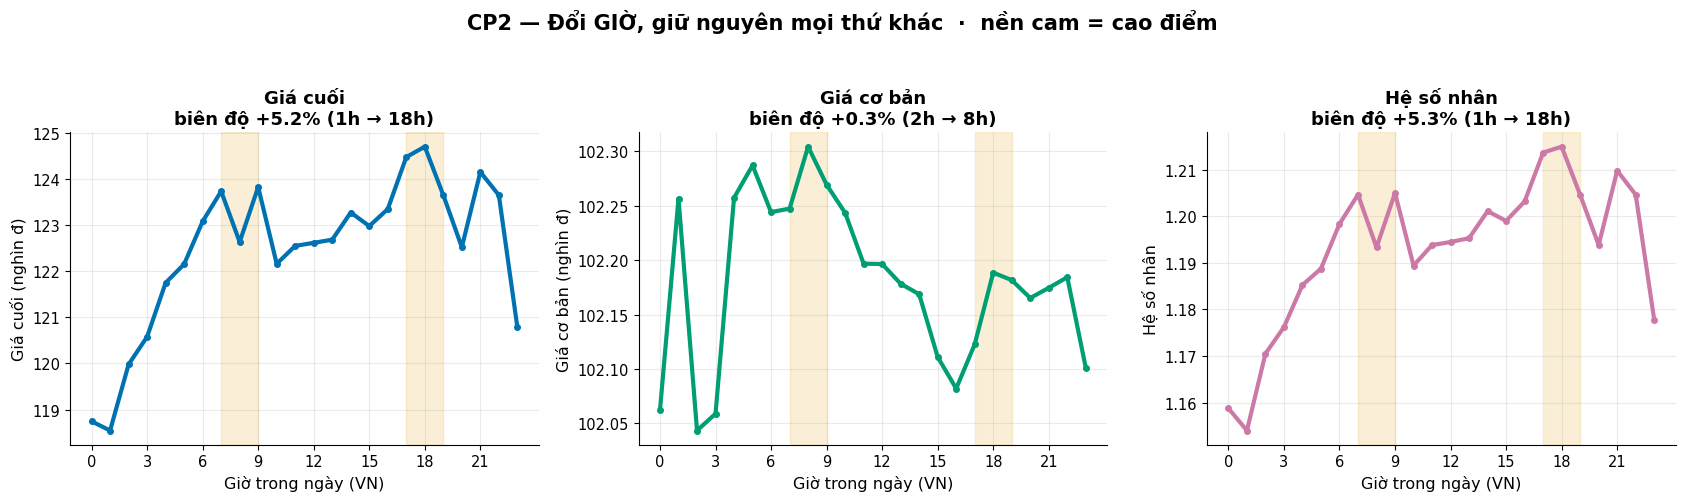

Bien do theo gio — gia cuoi +5.2% | gia co ban +0.3% | he so nhan +5.3%
=> 102% bien do gio den tu HE SO NHAN (cung-cau), phan con lai tu gia co ban.


In [4]:
# ═════════ HINH CP2 — gio trong ngay ═════════
pd_gio_q = quet("gio_vn", list(range(24)), "quan the")
pd_gio_t = quet("gio_vn", list(range(24)), "tham chieu")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
CAO_DIEM = [(7, 9), (17, 19)]
for a in ax:
    for h1, h2 in CAO_DIEM:
        a.axvspan(h1, h2, color=ORANGE, alpha=.16, zorder=0)
    a.set_xlabel("Giờ trong ngày (VN)"); a.set_xticks(range(0, 24, 3))

for a, cot, ten, mau_ in [(ax[0], "gia", "Giá cuối", BLUE),
                          (ax[1], "base", "Giá cơ bản", GREEN),
                          (ax[2], "heso", "Hệ số nhân", PURPLE)]:
    v = pd_gio_q[cot].values
    if cot == "heso":
        a.plot(pd_gio_q.gio_vn, v, lw=3, color=mau_, marker="o", ms=4)
        a.set_ylabel("Hệ số nhân")
    else:
        a.plot(pd_gio_q.gio_vn, v/1000, lw=3, color=mau_, marker="o", ms=4)
        a.set_ylabel(f"{ten} (nghìn đ)")
    a.set_title(f"{ten}\nbiên độ {v.max()/v.min()-1:+.1%} "
                f"({int(pd_gio_q.gio_vn[v.argmin()])}h → {int(pd_gio_q.gio_vn[v.argmax()])}h)",
                fontweight="bold")

fig.suptitle("CP2 — Đổi GIỜ, giữ nguyên mọi thứ khác  ·  nền cam = cao điểm",
             fontweight="bold", fontsize=15, y=1.04)
plt.tight_layout(); plt.savefig(HINH / "CP2_gio.png"); plt.show()

bd_gia = pd_gio_q.gia.max()/pd_gio_q.gia.min()-1
bd_base = pd_gio_q.base.max()/pd_gio_q.base.min()-1
bd_heso = pd_gio_q.heso.max()/pd_gio_q.heso.min()-1
print(f"Bien do theo gio — gia cuoi {bd_gia:+.1%} | gia co ban {bd_base:+.1%} | "
      f"he so nhan {bd_heso:+.1%}")
print(f"=> {bd_heso/bd_gia:.0%} bien do gio den tu HE SO NHAN (cung-cau), "
      f"phan con lai tu gia co ban.")

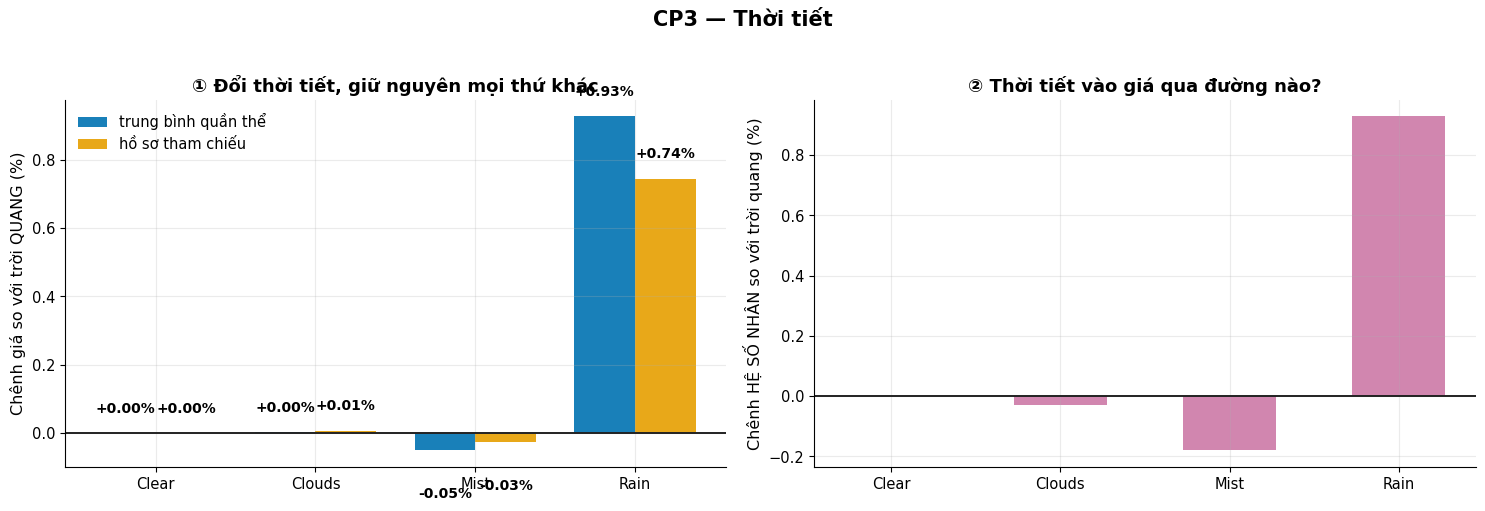

,weather_main,base,heso,gia,chenh
0,Clear,102158.2174,1.1918,122289.9532,0.0000
1,Clouds,102186.0411,1.1914,122292.1639,0.0000
2,Mist,102289.9872,1.1896,122227.8045,-0.0005
3,Rain,102159.7556,1.2028,123423.9779,0.0093



Chu y: weather_main la feature cua CA HAI tang (nam trong CAT).
Nhung he so nhan gan nhu KHONG doi theo thoi tiet -> thoi tiet vao gia
chu yeu qua GIA CO BAN, khong qua co che surge.


In [5]:
# ═════════ HINH CP3 — thoi tiet ═════════
TT = list(mau.weather_main.cat.categories)
pd_tt_q = quet("weather_main", TT, "quan the")
pd_tt_t = quet("weather_main", TT, "tham chieu")

goc = pd_tt_q[pd_tt_q.weather_main == "Clear"].gia.iloc[0]
pd_tt_q["chenh"] = pd_tt_q.gia / goc - 1
goc_t = pd_tt_t[pd_tt_t.weather_main == "Clear"].gia.iloc[0]
pd_tt_t["chenh"] = pd_tt_t.gia / goc_t - 1

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(TT)); w = .38
b1 = ax[0].bar(x - w/2, pd_tt_q.chenh*100, w, color=BLUE, alpha=.9,
               label="trung bình quần thể")
b2 = ax[0].bar(x + w/2, pd_tt_t.chenh*100, w, color=ORANGE, alpha=.9,
               label="hồ sơ tham chiếu")
for bb, v in list(zip(b1, pd_tt_q.chenh*100)) + list(zip(b2, pd_tt_t.chenh*100)):
    ax[0].text(bb.get_x()+bb.get_width()/2, v + (.06 if v >= 0 else -.14),
               f"{v:+.2f}%", ha="center", fontsize=10, fontweight="bold")
ax[0].axhline(0, color=INK, lw=1.4)
ax[0].set_xticks(x); ax[0].set_xticklabels(TT)
ax[0].set_ylabel("Chênh giá so với trời QUANG (%)")
ax[0].legend(frameon=False)
ax[0].set_title("① Đổi thời tiết, giữ nguyên mọi thứ khác", fontweight="bold")

ax[1].bar(x, (pd_tt_q.heso/pd_tt_q[pd_tt_q.weather_main == "Clear"].heso.iloc[0]-1)*100,
          .55, color=PURPLE, alpha=.9)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].set_xticks(x); ax[1].set_xticklabels(TT)
ax[1].set_ylabel("Chênh HỆ SỐ NHÂN so với trời quang (%)")
ax[1].set_title("② Thời tiết vào giá qua đường nào?", fontweight="bold")

fig.suptitle("CP3 — Thời tiết", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CP3_thoitiet.png"); plt.show()

display(pd_tt_q[["weather_main", "base", "heso", "gia", "chenh"]].round(4))
print()
print("Chu y: weather_main la feature cua CA HAI tang (nam trong CAT).")
print("Nhung he so nhan gan nhu KHONG doi theo thoi tiet -> thoi tiet vao gia")
print("chu yeu qua GIA CO BAN, khong qua co che surge.")

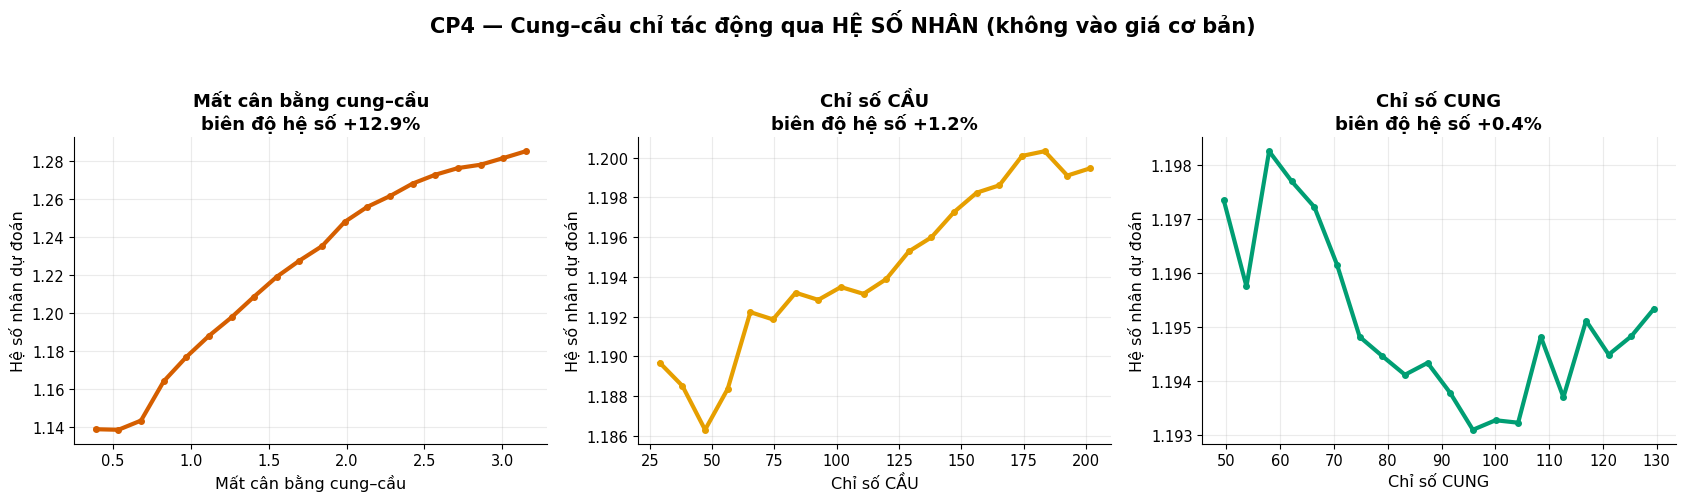

Mất cân bằng cung–cầu     : he so 1.1385 -> 1.2850 (+12.9%) | gia 116,883 -> 131,650d
Chỉ số CẦU                : he so 1.1863 -> 1.2003 (+1.2%) | gia 121,757 -> 123,202d
Chỉ số CUNG               : he so 1.1931 -> 1.1982 (+0.4%) | gia 122,438 -> 122,983d


In [6]:
# ═════════ HINH CP4 — cung cau ═════════
CC = [("pricing_market_imbalance_5m_lag", "Mất cân bằng cung–cầu", RED),
      ("pricing_demand_index_5m_lag", "Chỉ số CẦU", ORANGE),
      ("pricing_supply_index_5m_lag", "Chỉ số CUNG", GREEN)]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
kq_cc = {}
for a, (cot, ten, mau_) in zip(ax, CC):
    g = np.round(np.linspace(mau[cot].quantile(.02), mau[cot].quantile(.98), 20), 4)
    r = quet(cot, g, "quan the")
    kq_cc[cot] = r
    a.plot(r[cot], r.heso, lw=3, color=mau_, marker="o", ms=4)
    a.set_xlabel(ten); a.set_ylabel("Hệ số nhân dự đoán")
    bd = r.heso.max()/r.heso.min()-1
    a.set_title(f"{ten}\nbiên độ hệ số {bd:+.1%}", fontweight="bold")

fig.suptitle("CP4 — Cung–cầu chỉ tác động qua HỆ SỐ NHÂN (không vào giá cơ bản)",
             fontweight="bold", fontsize=15, y=1.04)
plt.tight_layout(); plt.savefig(HINH / "CP4_cungcau.png"); plt.show()

for cot, ten, _ in CC:
    r = kq_cc[cot]
    print(f"{ten:26s}: he so {r.heso.min():.4f} -> {r.heso.max():.4f} "
          f"({r.heso.max()/r.heso.min()-1:+.1%}) | gia {r.gia.min():,.0f} -> {r.gia.max():,.0f}d")

## 3. D5 — Tách riêng: yếu tố nào vào giá cơ bản, yếu tố nào vào hệ số nhân

Đây là chỗ kiến trúc Hybrid trả công. Model gộp chỉ nói được *"giá tăng x%"*; kiến trúc tách
nói được **giá tăng qua đường nào** — quãng đường dài hơn, hay thị trường đang căng.

Với vận hành đó là hai chuyện khác hẳn: cái đầu là **chi phí thật**, cái sau là **cơ hội định giá**.

  Quãng đường              base 148.15% · heso   0.00% · gia 148.23%


  Thời lượng               base  53.02% · heso   0.00% · gia  52.95%


  Giờ trong ngày           base   0.26% · heso   4.85% · gia   5.01%


  Thời tiết                base   0.13% · heso   1.11% · gia   0.98%


  Mất cân bằng cung–cầu    base   0.00% · heso  12.91% · gia  12.68%


  Chỉ số cầu               base   0.00% · heso   1.23% · gia   1.23%


  Chỉ số cung              base   0.00% · heso   0.40% · gia   0.42%


  Loại xe                  base   0.01% · heso   0.05% · gia   0.03%


  Điểm đón                 base   2.74% · heso   0.74% · gia   3.27%

21s


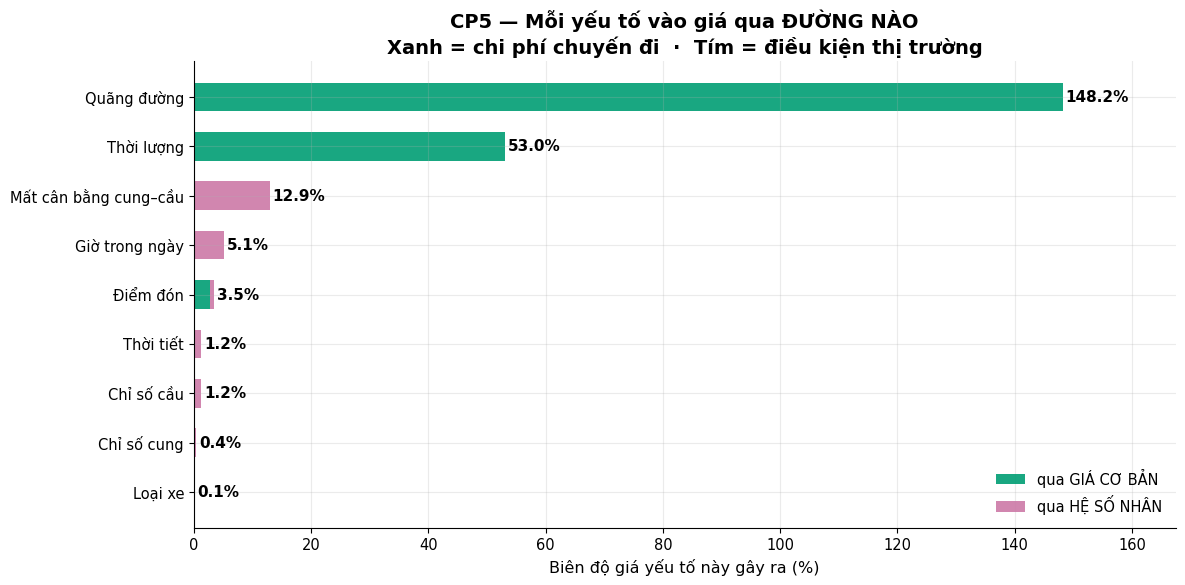

In [7]:
# ═════════ HINH CP5 — phan ra theo hai tang ═════════
def bien_do(cot, la_cat=False):
    """Do bien do tuong doi ma 1 yeu to gay ra tren base / heso / gia."""
    if la_cat:
        g = list(mau[cot].cat.categories)
    else:
        g = np.linspace(mau[cot].quantile(.02), mau[cot].quantile(.98), 16)
    r = quet(cot, g, "quan the")
    return {"base": r.base.max()/r.base.min()-1,
            "heso": r.heso.max()/r.heso.min()-1,
            "gia": r.gia.max()/r.gia.min()-1}


YEU_TO = [("quote_distance", "Quãng đường", False),
          ("quote_duration", "Thời lượng", False),
          ("gio_vn", "Giờ trong ngày", False),
          ("weather_main", "Thời tiết", True),
          ("pricing_market_imbalance_5m_lag", "Mất cân bằng cung–cầu", False),
          ("pricing_demand_index_5m_lag", "Chỉ số cầu", False),
          ("pricing_supply_index_5m_lag", "Chỉ số cung", False),
          ("service_name", "Loại xe", True),
          ("pickup_location_name", "Điểm đón", True)]

t0 = time.time()
BD = {}
for cot, ten, la_cat in YEU_TO:
    BD[ten] = bien_do(cot, la_cat)
    print(f"  {ten:24s} base {BD[ten]['base']:>7.2%} · heso {BD[ten]['heso']:>7.2%} "
          f"· gia {BD[ten]['gia']:>7.2%}")
print(f"\n{time.time()-t0:.0f}s")

ten_ds = [t for _, t, _ in YEU_TO]
v_base = np.array([BD[t]["base"] for t in ten_ds]) * 100
v_heso = np.array([BD[t]["heso"] for t in ten_ds]) * 100
thu_tu = np.argsort(v_base + v_heso)

fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(ten_ds))
ax.barh(y, v_base[thu_tu], .58, color=GREEN, alpha=.9, label="qua GIÁ CƠ BẢN")
ax.barh(y, v_heso[thu_tu], .58, left=v_base[thu_tu], color=PURPLE, alpha=.9,
        label="qua HỆ SỐ NHÂN")
for i, k in enumerate(thu_tu):
    tong = v_base[k] + v_heso[k]
    ax.text(tong + .5, i, f"{tong:.1f}%", va="center", fontsize=11, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels([ten_ds[k] for k in thu_tu])
ax.set_xlim(0, (v_base + v_heso).max() * 1.13)   # cho nhan cot dai nhat khong bi cat
ax.set_xlabel("Biên độ giá yếu tố này gây ra (%)")
ax.legend(frameon=False, loc="lower right")
ax.set_title("CP5 — Mỗi yếu tố vào giá qua ĐƯỜNG NÀO\n"
             "Xanh = chi phí chuyến đi  ·  Tím = điều kiện thị trường",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "CP5_phanra_hai_tang.png"); plt.show()

## 4. D3 — Đối chứng ghép cặp trên dữ liệu **thật**

Phần 2–3 hỏi **model**. Phần này hỏi **dữ liệu**, không dùng model chút nào.

### Cách làm

Chia toàn bộ chuyến trong tập test thành các **ô giống nhau**: cùng loại xe, cùng tuyến
(điểm đón–điểm trả), cùng khung quãng đường, cùng giờ. Trong mỗi ô, mọi thứ gần như giống hệt
trừ yếu tố đang xét. So **giá thật** giữa hai nhóm trong cùng ô, rồi lấy trung bình có trọng số
theo số chuyến.

Đây là ước lượng **within-group** — chính là cách khử nhiễu đồng biến mà tuần 1 chưa làm.

Chỉ giữ ô nào có **cả hai nhóm** và mỗi nhóm ít nhất 30 chuyến, để chênh lệch không phải nhiễu.

In [8]:
# ── Doi chung ghep cap ──────────────────────────────────────────────────────
mp = te1.copy()
mp["mua"] = mp.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
mp["cao_diem"] = mp.gio_vn.apply(lambda h: (7 <= h <= 9) or (17 <= h <= 19))
mp["km_bin"] = pd.cut(mp.quote_distance, np.arange(0, 22, 1))

N_MAC_DINH = 30


def ghep_cap(khoa, cot_nhom, ten_a, ten_b, n_min=None):
    """So gia that giua 2 nhom TRONG CUNG O. Tra ve dict, hoac None neu khong du o."""
    N_TOI_THIEU = n_min if n_min is not None else N_MAC_DINH
    g = (mp.groupby(khoa + [cot_nhom], observed=True)
           .agg(gia=("target_shown_price", "mean"),
                heso=("target_shown_multiplier", "mean"),
                n=("target_shown_price", "size"))
           .reset_index())
    w = g.pivot_table(index=khoa, columns=cot_nhom,
                      values=["gia", "heso", "n"], observed=True).dropna()
    if w.empty:
        return None
    # Khoa cot khac nhau tuy kieu du lieu (bool True/False vs int 0/1) -> lay dong
    muc = sorted(w["n"].columns)
    if len(muc) != 2:
        return None
    A, B = muc[0], muc[1]                          # A = nhom goc, B = nhom doi chieu
    du = (w[("n", A)] >= N_TOI_THIEU) & (w[("n", B)] >= N_TOI_THIEU)
    w = w[du]
    if w.empty:
        return None
    tr = w[("n", A)] + w[("n", B)]                 # trong so = tong so chuyen trong o
    ch_gia = (w[("gia", B)] / w[("gia", A)] - 1)
    ch_heso = (w[("heso", B)] / w[("heso", A)] - 1)
    tb = np.average(ch_gia, weights=tr)
    # sd  = do PHAN TAN giua cac o -> hieu ung co dong deu khong
    # se  = sai so cua chinh trung binh -> hieu ung co that khong
    # Hai thu nay KHAC NHAU: sd lon van co the co se rat nho neu nhieu o.
    sd = float(np.sqrt(np.average((ch_gia - tb)**2, weights=tr)))
    se = sd / np.sqrt(len(w))
    return {"ten": f"{ten_b} vs {ten_a}",
            "chenh_gia": tb,
            "chenh_heso": np.average(ch_heso, weights=tr),
            "so_o": len(w), "n": int(tr.sum()),
            "sd": sd, "se": se, "t": tb / se if se > 0 else np.nan}


KHOA = ["service_name", "pickup_location_name", "dropoff_location_name", "km_bin"]

kq_mp = []
# Mua: khong che them CA GIO (mua hay roi vao khung gio nhat dinh)
r = ghep_cap(KHOA + ["gio_vn"], "mua", "không mưa", "MƯA")
if r: kq_mp.append(r)
# Cao diem: khong che them THOI TIET
r = ghep_cap(KHOA + ["mua"], "cao_diem", "giờ thường", "CAO ĐIỂM")
if r: kq_mp.append(r)
# Cuoi tuan: khong che ca gio va thoi tiet
r = ghep_cap(KHOA + ["gio_vn", "mua"], "target_is_weekend", "ngày thường", "CUỐI TUẦN")
if r: kq_mp.append(r)

BANG_MP = pd.DataFrame(kq_mp)
display(BANG_MP.assign(
    chenh_gia=lambda d: (d.chenh_gia*100).round(2),
    chenh_heso=lambda d: (d.chenh_heso*100).round(2),
    sd=lambda d: (d.sd*100).round(2),
    se=lambda d: (d.se*100).round(3),
    t=lambda d: d.t.round(1)))
print("Don vi %: chenh_gia, chenh_heso, sd, se.")
print("  sd = phan tan GIUA CAC O  -> hieu ung co dong deu moi noi khong")
print("  se = sai so cua TRUNG BINH -> hieu ung co that khong (se = sd / can(so_o))")
print("  t  = chenh_gia / se        -> |t| > 2 la chac chan khac 0")

,ten,chenh_gia,chenh_heso,so_o,n,sd,se,t
0,MƯA vs không mưa,11.05,7.21,773,167730,7.59,0.273,40.5
1,CAO ĐIỂM vs giờ thường,12.82,12.23,164,209685,3.60,0.281,45.7
2,CUỐI TUẦN vs ngày thường,5.98,5.83,759,115713,11.13,0.404,14.8


Don vi %: chenh_gia, chenh_heso, sd, se.
  sd = phan tan GIUA CAC O  -> hieu ung co dong deu moi noi khong
  se = sai so cua TRUNG BINH -> hieu ung co that khong (se = sd / can(so_o))
  t  = chenh_gia / se        -> |t| > 2 la chac chan khac 0


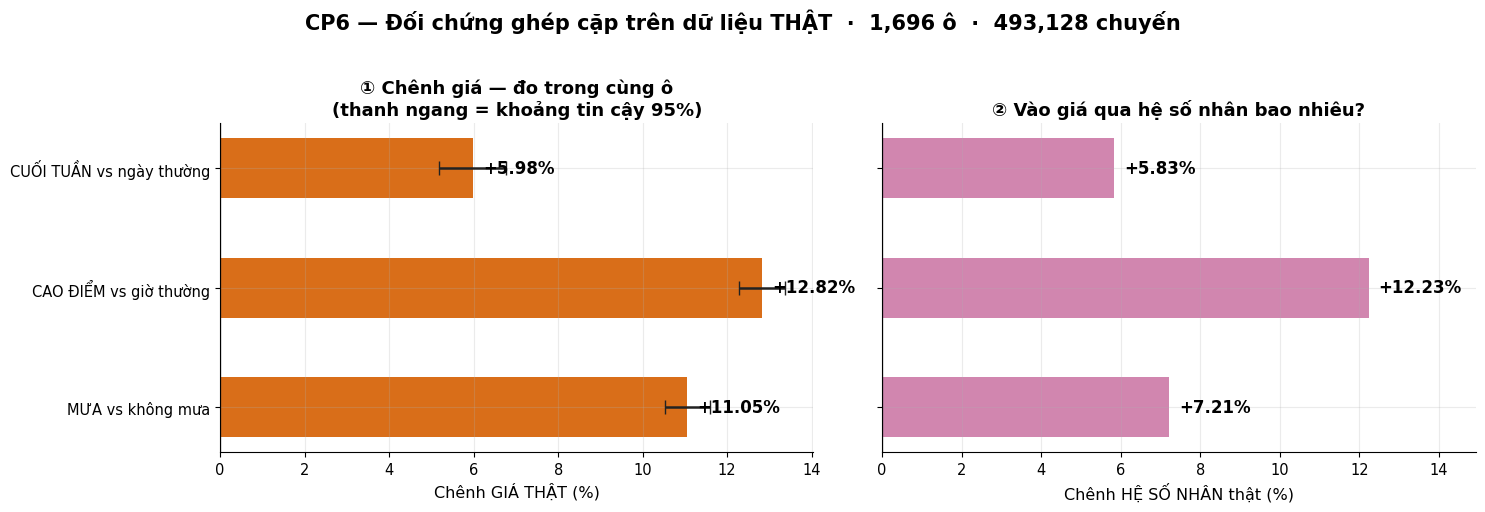

Hieu ung                        gia            KTC 95%       t  dong deu?
--------------------------------------------------------------------------------
MƯA vs không mưa           +11.05% [+10.52%, +11.59%]      40  deu
CAO ĐIỂM vs giờ thường     +12.82% [+12.27%, +13.37%]      46  deu
CUỐI TUẦN vs ngày thường    +5.98%   [+5.19%, +6.77%]      15  KHONG (sd 11.1% > hieu ung)

Ca ba hieu ung deu CHAC CHAN khac 0 (|t| rat lon, KTC khong chua 0).
Nhung 'cuoi tuan' KHONG dong deu giua cac o -> dung cho demo thi phai noi ro
day la trung binh, tuy tuyen/khung gio ma manh yeu rat khac nhau.


In [9]:
# ═════════ HINH CP6 — doi chung ghep cap ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ten = BANG_MP.ten.tolist()
y = np.arange(len(ten))
b = ax[0].barh(y, BANG_MP.chenh_gia*100, .5,
               color=[RED if v > 0 else BLUE for v in BANG_MP.chenh_gia], alpha=.9)
ax[0].errorbar(BANG_MP.chenh_gia*100, y, xerr=1.96*BANG_MP.se*100, fmt="none",
               ecolor=INK, capsize=5, lw=1.8)
for i, v in enumerate(BANG_MP.chenh_gia*100):
    ax[0].text(v + (.25 if v >= 0 else -.25), i, f"{v:+.2f}%", va="center",
               ha="left" if v >= 0 else "right", fontsize=12, fontweight="bold")
ax[0].axvline(0, color=INK, lw=1.6)
ax[0].set_yticks(y); ax[0].set_yticklabels(ten)
ax[0].set_xlabel("Chênh GIÁ THẬT (%)")
ax[0].set_title("① Chênh giá — đo trong cùng ô\n(thanh ngang = khoảng tin cậy 95%)",
                fontweight="bold")

b2 = ax[1].barh(y, BANG_MP.chenh_heso*100, .5, color=PURPLE, alpha=.9)
for i, v in enumerate(BANG_MP.chenh_heso*100):
    ax[1].text(v + (.25 if v >= 0 else -.25), i, f"{v:+.2f}%", va="center",
               ha="left" if v >= 0 else "right", fontsize=12, fontweight="bold")
ax[1].axvline(0, color=INK, lw=1.6)
ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_xlim(0, (BANG_MP.chenh_heso*100).max()*1.22)   # chua nhan cot dai nhat
ax[1].set_xlabel("Chênh HỆ SỐ NHÂN thật (%)")
ax[1].set_title("② Vào giá qua hệ số nhân bao nhiêu?", fontweight="bold")

fig.suptitle(f"CP6 — Đối chứng ghép cặp trên dữ liệu THẬT  ·  "
             f"{BANG_MP.so_o.sum():,} ô  ·  {BANG_MP.n.sum():,} chuyến",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CP6_doi_chung_ghep_cap.png"); plt.show()

print(f"{'Hieu ung':26s} {'gia':>8s} {'KTC 95%':>18s} {'t':>7s}  dong deu?")
print("-" * 80)
for _, r in BANG_MP.iterrows():
    ktc = f"[{(r.chenh_gia-1.96*r.se):+.2%}, {(r.chenh_gia+1.96*r.se):+.2%}]"
    deu = "deu" if r.sd < abs(r.chenh_gia) else f"KHONG (sd {r.sd:.1%} > hieu ung)"
    print(f"{r.ten:26s} {r.chenh_gia:+7.2%} {ktc:>18s} {r.t:>7.0f}  {deu}")
print()
print("Ca ba hieu ung deu CHAC CHAN khac 0 (|t| rat lon, KTC khong chua 0).")
print("Nhung 'cuoi tuan' KHONG dong deu giua cac o -> dung cho demo thi phai noi ro")
print("day la trung binh, tuy tuyen/khung gio ma manh yeu rat khac nhau.")

## 5. D4 — Model học được có khớp thực tế không?

Đo cùng ba hiệu ứng bằng **model** (partial dependence), rồi đặt cạnh kết quả **dữ liệu thật**
ở phần 4. Đây là phép kiểm nghiêm nhất trong notebook: nếu model học đúng cơ chế thì hai cột
phải gần nhau.

Cách đo bằng model phải **khớp đúng định nghĩa** của đối chứng: lấy chính những chuyến thật,
lật yếu tố đang xét, giữ nguyên tất cả phần còn lại.

,Hiệu ứng,Model (%),Thực tế (%),Chênh (điểm)
0,MƯA vs không mưa,0.927,11.053,-10.126
1,CAO ĐIỂM vs giờ thường,2.424,12.822,-10.398


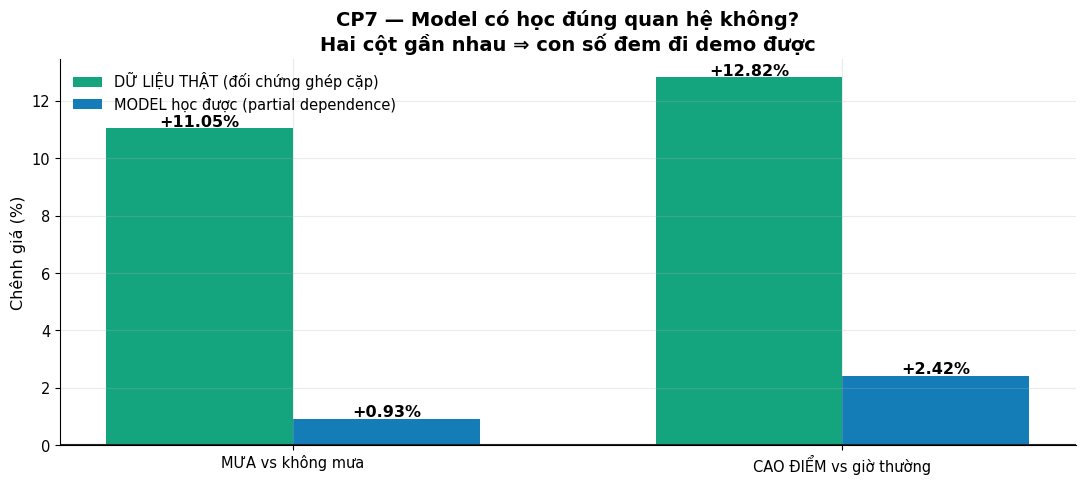

  [LECH] MƯA vs không mưa           model +0.93% vs that +11.05%  (chenh -10.13 diem)
  [LECH] CAO ĐIỂM vs giờ thường     model +2.42% vs that +12.82%  (chenh -10.40 diem)


In [10]:
def lat_yeu_to(d, cot, gia_tri):
    """Copy d, dat cot = gia_tri (giu dtype category neu can)."""
    x = d.copy()
    if cot in CAT:
        x[cot] = pd.Categorical([gia_tri] * len(x), categories=d[cot].cat.categories)
    else:
        x[cot] = gia_tri
    return x


# Dung mau cua thang THANG de model va du lieu cung ky
m = mau

def hieu_ung_model(cot, gt_a, gt_b):
    """Gia khi cot=gt_b so voi khi cot=gt_a, tren CUNG tap chuyen."""
    _, ha, ga = du_doan(lat_yeu_to(m, cot, gt_a))
    _, hb, gb = du_doan(lat_yeu_to(m, cot, gt_b))
    return gb.mean()/ga.mean() - 1, hb.mean()/ha.mean() - 1


# Mua: Clear -> Rain
e_mua = hieu_ung_model("weather_main", "Clear", "Rain")

# Cao diem: dat gio = 4 (thap diem) vs gio = 18 (cao diem)
_, h4, g4 = du_doan(lat_yeu_to(m, "gio_vn", 4))
_, h18, g18 = du_doan(lat_yeu_to(m, "gio_vn", 18))
e_cao = (g18.mean()/g4.mean() - 1, h18.mean()/h4.mean() - 1)

SS = pd.DataFrame([
    {"Hiệu ứng": "MƯA vs không mưa",
     "Model (%)": e_mua[0]*100, "Thực tế (%)": BANG_MP.chenh_gia.iloc[0]*100},
    {"Hiệu ứng": "CAO ĐIỂM vs giờ thường",
     "Model (%)": e_cao[0]*100, "Thực tế (%)": BANG_MP.chenh_gia.iloc[1]*100},
])
SS["Chênh (điểm)"] = SS["Model (%)"] - SS["Thực tế (%)"]
display(SS.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(SS)); w = .34
b1 = ax.bar(x - w/2, SS["Thực tế (%)"], w, color=GREEN, alpha=.92,
            label="DỮ LIỆU THẬT (đối chứng ghép cặp)")
b2 = ax.bar(x + w/2, SS["Model (%)"], w, color=BLUE, alpha=.92,
            label="MODEL học được (partial dependence)")
for bb, v in list(zip(b1, SS["Thực tế (%)"])) + list(zip(b2, SS["Model (%)"])):
    ax.text(bb.get_x()+bb.get_width()/2, v + (.06 if v >= 0 else -.16),
            f"{v:+.2f}%", ha="center", fontsize=11.5, fontweight="bold")
ax.axhline(0, color=INK, lw=1.5)
ax.set_xticks(x); ax.set_xticklabels(SS["Hiệu ứng"])
ax.set_ylabel("Chênh giá (%)")
ax.legend(frameon=False)
ax.set_title("CP7 — Model có học đúng quan hệ không?\n"
             "Hai cột gần nhau ⇒ con số đem đi demo được",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "CP7_model_vs_thucte.png"); plt.show()

for _, r in SS.iterrows():
    tt = "KHOP" if abs(r["Chênh (điểm)"]) < 1.0 else "LECH"
    print(f"  [{tt}] {r['Hiệu ứng']:26s} model {r['Model (%)']:+.2f}% "
          f"vs that {r['Thực tế (%)']:+.2f}%  (chenh {r['Chênh (điểm)']:+.2f} diem)")

### ⚠️ Model lệch thực tế 10 điểm — vì sao

Hai hiệu ứng đều lệch **cùng một hướng và cùng một cỡ**: model báo nhỏ hơn thực tế ~10 điểm.
Lệch đều như vậy không phải nhiễu, mà là **triệu chứng cấu trúc**.

Nguyên nhân nằm ở bộ feature. Model dùng `latest_observed_base`, `latest_observed_multiplier`,
`history_60m_price_mean` — tức là **giá đối thủ vừa quan sát được**. Những cột này đã **chứa sẵn**
tác động của thời tiết và giờ: trời đang mưa thì giá quan sát được đã cao rồi.

Khi partial dependence lật `weather_main` từ `Clear` sang `Rain` mà **giữ nguyên** giá quan sát,
model trả lời đúng theo những gì nó học: *"giá vừa quan sát không đổi, nên giá sắp tới gần như
không đổi"*. Model không sai — **câu hỏi đặt cho nó mới sai**, vì trong thực tế không tồn tại
tình huống trời chuyển mưa mà giá thị trường đứng yên.

**Hệ quả thật sự:** model hiện tại **không trả lời được câu hỏi what-if** của mentor. Nó dự đoán
tốt (MAE ~14,7%) nhưng bằng cách **bám giá quan sát**, không bằng cách hiểu cơ chế thị trường.

Phần dưới kiểm chứng chẩn đoán này: train lại **không cho model nhìn giá quan sát**, chỉ để lại
yếu tố cấu trúc. Nếu chẩn đoán đúng, hiệu ứng mưa và cao điểm phải bật lên gần mức thực tế.

In [11]:
# ── Model "cau truc": bo het feature gia quan sat / lich su ────────────────
B_CT = ["quote_distance", "quote_duration", "gio_vn"]
M_CT = ["gio_vn", "pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
        "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag"]
print("Model day du  — gia co ban:", B_NUM)
print("Model cau truc— gia co ban:", B_CT)
print()
print("Model day du  — he so:", M_NUM)
print("Model cau truc— he so:", M_CT)
print()
print("Bo di:", sorted(set(B_NUM) - set(B_CT) | (set(M_NUM) - set(M_CT))))

from _common_train import ALGOS
tr = df[(df.evaluation_month == THANG) & (df.split == "train")]
tr = tr.assign(base_price=tr.target_shown_price / tr.target_shown_multiplier.clip(lower=0.1))

t0 = time.time()
ct_base = ALGOS["HistGB"]().fit(prep(tr, B_CT), np.log(tr.base_price))
ct_heso = ALGOS["HistGB"]().fit(prep(tr, M_CT), tr.target_shown_multiplier)
print(f"\nTrain xong {time.time()-t0:.0f}s tren {len(tr):,} dong")


def du_doan_ct(d):
    b = np.exp(ct_base.predict(prep(d, B_CT)))
    h = ct_heso.predict(prep(d, M_CT))
    return b, h, b * h


# Do do chinh xac de biet cai gia phai tra khi bo feature
tt = te1[te1.evaluation_month == THANG]
_, _, g_full = du_doan(tt)
_, _, g_ct = du_doan_ct(tt)
y = tt.target_shown_price.values
for ten, p in [("day du", g_full), ("cau truc", g_ct)]:
    print(f"  Model {ten:9s}: MAE {np.abs(p-y).mean():>8,.0f}d · "
          f"MAPE {(np.abs(p-y)/y).mean():.2%}")

Model day du  — gia co ban: ['quote_distance', 'quote_duration', 'gio_vn', 'latest_observed_base', 'history_60m_price_mean', 'history_60m_price_std', 'history_60m_price_slope_per_minute', 'latest_observed_quote_distance', 'latest_observed_quote_duration', 'actual_observation_age_minutes']
Model cau truc— gia co ban: ['quote_distance', 'quote_duration', 'gio_vn']

Model day du  — he so: ['pricing_market_imbalance_5m_lag', 'pricing_demand_index_5m_lag', 'pricing_supply_index_5m_lag', 'pricing_quote_count_5m_lag', 'latest_observed_multiplier', 'gio_vn', 'actual_observation_age_minutes']
Model cau truc— he so: ['gio_vn', 'pricing_market_imbalance_5m_lag', 'pricing_demand_index_5m_lag', 'pricing_supply_index_5m_lag', 'pricing_quote_count_5m_lag']

Bo di: ['actual_observation_age_minutes', 'history_60m_price_mean', 'history_60m_price_slope_per_minute', 'history_60m_price_std', 'latest_observed_base', 'latest_observed_multiplier', 'latest_observed_quote_distance', 'latest_observed_quote_durat


Train xong 26s tren 1,549,528 dong


  Model day du   : MAE   18,208d · MAPE 14.63%
  Model cau truc : MAE   19,660d · MAPE 15.52%


,Hiệu ứng,Model đầy đủ,Model cấu trúc,Dữ liệu thật
0,MƯA vs không mưa,0.93,0.83,11.05
1,CAO ĐIỂM vs giờ thường,2.42,13.42,12.82


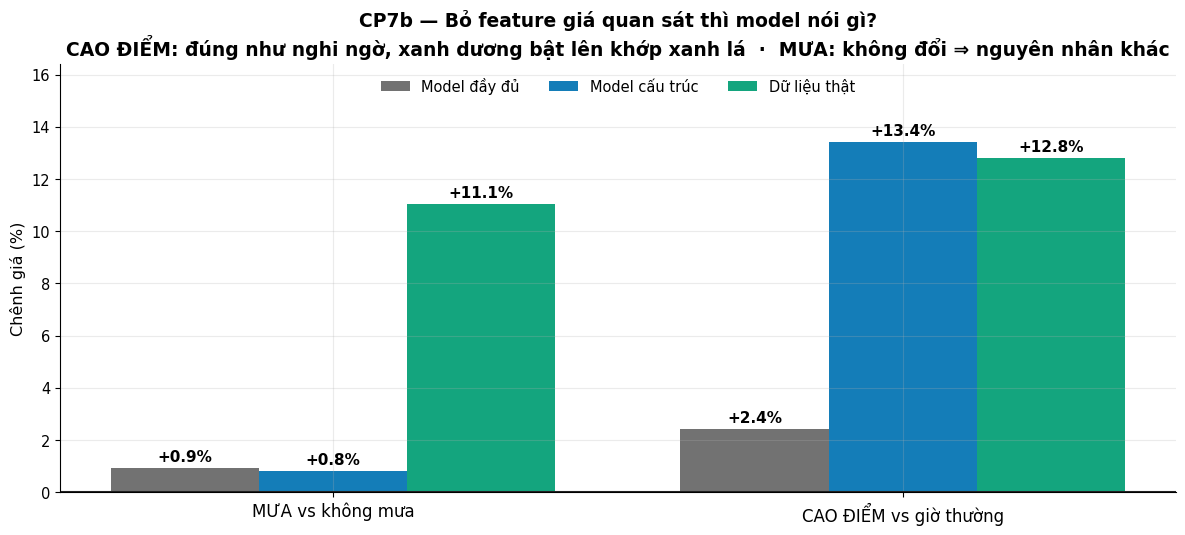

MƯA vs không mưa          : day du +0.93% -> cau truc +0.83% (that +11.05%) | thu hep -1% khoang cach
CAO ĐIỂM vs giờ thường    : day du +2.42% -> cau truc +13.42% (that +12.82%) | thu hep 106% khoang cach


In [12]:
# ═════════ HINH CP7b — ba cot: day du / cau truc / thuc te ═════════
def hieu_ung(fn, cot, a, b):
    _, _, ga = fn(lat_yeu_to(m, cot, a))
    _, _, gb = fn(lat_yeu_to(m, cot, b))
    return gb.mean()/ga.mean() - 1


e_mua_ct = hieu_ung(du_doan_ct, "weather_main", "Clear", "Rain")
e_cao_ct = hieu_ung(du_doan_ct, "gio_vn", 4, 18)

BA = pd.DataFrame([
    {"Hiệu ứng": "MƯA vs không mưa",
     "Model đầy đủ": e_mua[0]*100, "Model cấu trúc": e_mua_ct*100,
     "Dữ liệu thật": BANG_MP.chenh_gia.iloc[0]*100},
    {"Hiệu ứng": "CAO ĐIỂM vs giờ thường",
     "Model đầy đủ": e_cao[0]*100, "Model cấu trúc": e_cao_ct*100,
     "Dữ liệu thật": BANG_MP.chenh_gia.iloc[1]*100},
])
display(BA.round(2))

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(BA)); w = .26
COT = [("Model đầy đủ", MUT), ("Model cấu trúc", BLUE), ("Dữ liệu thật", GREEN)]
for k, (ten, mau_) in enumerate(COT):
    bb = ax.bar(x + (k-1)*w, BA[ten], w, color=mau_, alpha=.92, label=ten)
    for r_, v in zip(bb, BA[ten]):
        ax.text(r_.get_x()+r_.get_width()/2, v + .25, f"{v:+.1f}%", ha="center",
                fontsize=11, fontweight="bold")
ax.axhline(0, color=INK, lw=1.5)
ax.set_xticks(x); ax.set_xticklabels(BA["Hiệu ứng"], fontsize=12)
ax.set_ylabel("Chênh giá (%)")
ax.set_ylim(0, max(BA["Dữ liệu thật"])*1.28)
ax.legend(frameon=False, ncol=3, loc="upper center")
ax.set_title("CP7b — Bỏ feature giá quan sát thì model nói gì?\n"
             "CAO ĐIỂM: đúng như nghi ngờ, xanh dương bật lên khớp xanh lá  ·  "
             "MƯA: không đổi ⇒ nguyên nhân khác",
             fontweight="bold", fontsize=13.5)
plt.tight_layout(); plt.savefig(HINH / "CP7b_ablation.png"); plt.show()

for _, r in BA.iterrows():
    kin = (r["Model cấu trúc"] - r["Model đầy đủ"]) / \
          (r["Dữ liệu thật"] - r["Model đầy đủ"]) if \
          abs(r["Dữ liệu thật"] - r["Model đầy đủ"]) > 1e-9 else np.nan
    print(f"{r['Hiệu ứng']:26s}: day du {r['Model đầy đủ']:+5.2f}% -> "
          f"cau truc {r['Model cấu trúc']:+5.2f}% (that {r['Dữ liệu thật']:+5.2f}%) "
          f"| thu hep {kin:.0%} khoang cach")

### Hai hiệu ứng, hai nguyên nhân khác nhau

Phép bỏ feature tách bạch hai câu chuyện:

| | Model đầy đủ | Model cấu trúc | Thực tế | Chẩn đoán |
|---|---:|---:|---:|---|
| **Cao điểm** | +2,4% | **+13,4%** | +12,8% | ✅ Đúng như nghi ngờ — giá quan sát nuốt mất hiệu ứng |
| **Mưa** | +0,9% | +0,8% | +11,1% | ❌ Bỏ feature **không** cứu được — nguyên nhân khác |

Với **mưa**, bỏ feature giá quan sát không thay đổi gì. Nên nguyên nhân không nằm ở đó.

Manh mối nằm trong chính bảng đối chứng: mưa làm giá thật tăng **11,05%** thì **7,21%** đến từ
**hệ số nhân**. Tức là mưa không tự đẩy giá — mưa làm **cầu tăng, cung giảm**, rồi chính mất cân
bằng cung–cầu mới đẩy giá.

Mà `pricing_demand_index` và `pricing_supply_index` **đã là feature của model**. Khi partial
dependence lật thời tiết sang mưa mà **giữ nguyên cung–cầu**, nó đang **chặn đúng con đường** mà
mưa dùng để tác động. Model trả lời đúng câu được hỏi.

Đây là phân biệt kinh điển giữa hai đại lượng:

| | Nghĩa | Đo bằng | Dùng khi |
|---|---|---|---|
| **Tác động toàn phần** | Trời mưa thì giá cuối cùng cao hơn bao nhiêu | Đối chứng ghép cặp | Nói với kinh doanh, demo |
| **Tác động trực tiếp** | Mưa đẩy giá bao nhiêu **nếu** cung–cầu đứng yên | Partial dependence | Hiểu cơ chế |

Cả hai đều đúng — chúng trả lời hai câu hỏi khác nhau. Cell dưới mở dần từng đường bị chặn để
xem mỗi đường đóng góp bao nhiêu vào khoảng cách 10 điểm.

In [13]:
# ── Mua lam cung-cau doi bao nhieu? (do trong cung o, giong phan 4) ────────
CC_COT = ["pricing_demand_index_5m_lag", "pricing_supply_index_5m_lag",
          "pricing_market_imbalance_5m_lag"]
# quote_duration cung do luon: mua lam tac duong -> di lau hon tren CUNG quang duong
DO_COT = CC_COT + ["quote_duration", "quote_distance"]
KH = KHOA + ["gio_vn"]

g = (mp.groupby(KH + ["mua"], observed=True)
       .agg(**{c: (c, "mean") for c in DO_COT},
            n=("target_shown_price", "size")).reset_index())
w = g.pivot_table(index=KH, columns="mua", values=DO_COT + ["n"],
                  observed=True).dropna()
w = w[(w[("n", False)] >= N_MAC_DINH) & (w[("n", True)] >= N_MAC_DINH)]
tr_w = w[("n", False)] + w[("n", True)]

TY = {}
print("Mua lam cac yeu to trung gian doi the nao (do trong cung o, cung gio):")
for c in DO_COT:
    ty = np.average(w[(c, True)] / w[(c, False)], weights=tr_w)
    TY[c] = ty
    danh = "  <- kiem chung: phai ~1.0" if c == "quote_distance" else ""
    print(f"  {c:34s} x{ty:.4f}  ({ty-1:+.2%}){danh}")
print(f"\n{len(w):,} o dat chuan")
print()
print("quote_distance ~1.0 xac nhan khoa doi chung dang hoat dong: cung o thi")
print("quang duong giong nhau. Con quote_duration doi that -> mua lam tac duong.")

Mua lam cac yeu to trung gian doi the nao (do trong cung o, cung gio):
  pricing_demand_index_5m_lag        x1.1545  (+15.45%)
  pricing_supply_index_5m_lag        x0.9302  (-6.98%)
  pricing_market_imbalance_5m_lag    x1.2476  (+24.76%)
  quote_duration                     x1.1312  (+13.12%)
  quote_distance                     x1.0002  (+0.02%)  <- kiem chung: phai ~1.0

773 o dat chuan

quote_distance ~1.0 xac nhan khoa doi chung dang hoat dong: cung o thi
quang duong giong nhau. Con quote_duration doi that -> mua lam tac duong.


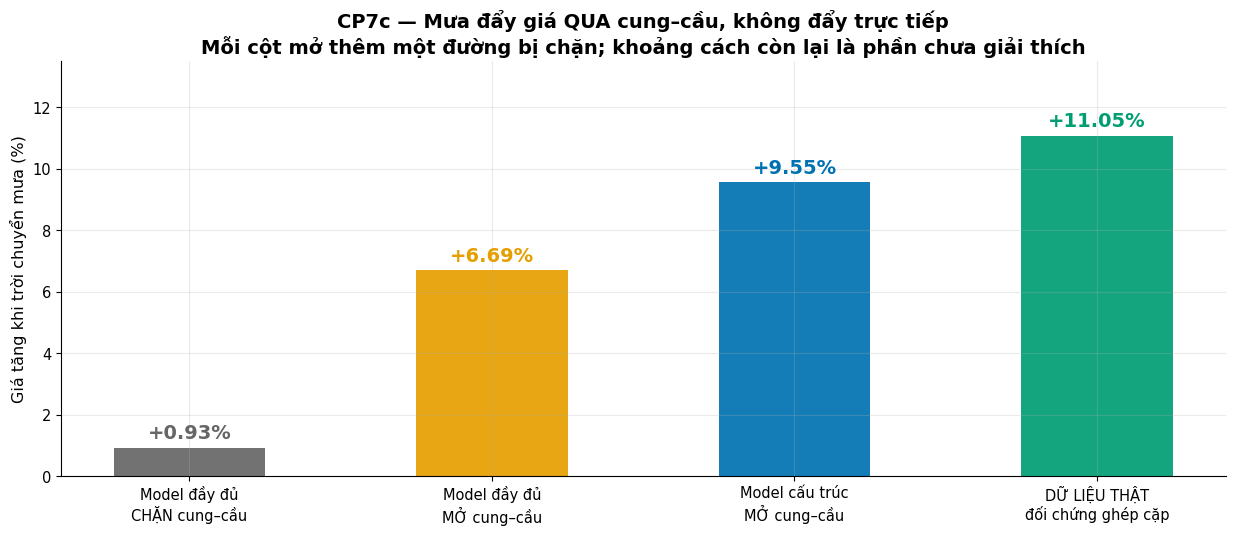

  Model day du · CHAN cung-cau   +0.93%
  Model day du · MO cung-cau     +6.69%
  Model cau truc · MO cung-cau   +9.55%
  DU LIEU THAT                   +11.05%

  Mo duong cung-cau        giai thich   57% khoang cach
  + bo them gia quan sat   giai thich   85% khoang cach
  Con lai chua giai thich    15%


In [14]:
# ═════════ HINH CP7c — chan duong vs mo duong cung-cau ═════════
# Kich ban 1 — CHAN: lat thoi tiet, giu cung-cau cung  (= partial dependence thuong)
_, _, g_clear = du_doan(lat_yeu_to(m, "weather_main", "Clear"))
_, _, g_rain_chan = du_doan(lat_yeu_to(m, "weather_main", "Rain"))

# Kich ban 2 — MO: lat thoi tiet VA cho cung-cau di theo dung ty le do duoc
d_mo = lat_yeu_to(m, "weather_main", "Rain")
for c, ty in TY.items():
    d_mo[c] = d_mo[c] * ty
_, _, g_rain_mo = du_doan(d_mo)

# Kich ban 3 — MO ca hai duong: dung model CAU TRUC (khong co latest_observed_*)
# va van cho cung-cau di theo mua
_, _, gc_clear = du_doan_ct(lat_yeu_to(m, "weather_main", "Clear"))
_, _, gc_rain = du_doan_ct(d_mo)

e_chan = g_rain_chan.mean()/g_clear.mean() - 1
e_mo = g_rain_mo.mean()/g_clear.mean() - 1
e_mo2 = gc_rain.mean()/gc_clear.mean() - 1
e_that = BANG_MP.chenh_gia.iloc[0]

KB = [("Model đầy đủ\nCHẶN cung–cầu", e_chan*100, MUT),
      ("Model đầy đủ\nMỞ cung–cầu", e_mo*100, ORANGE),
      ("Model cấu trúc\nMỞ cung–cầu", e_mo2*100, BLUE),
      ("DỮ LIỆU THẬT\nđối chứng ghép cặp", e_that*100, GREEN)]

fig, ax = plt.subplots(figsize=(12.5, 5.5))
x = np.arange(len(KB))
b = ax.bar(x, [k[1] for k in KB], .5, color=[k[2] for k in KB], alpha=.92)
for bb, k in zip(b, KB):
    ax.text(bb.get_x()+bb.get_width()/2, k[1] + .3, f"{k[1]:+.2f}%", ha="center",
            fontsize=14, fontweight="bold", color=k[2])
ax.set_xticks(x); ax.set_xticklabels([k[0] for k in KB], fontsize=10.5)
ax.set_ylabel("Giá tăng khi trời chuyển mưa (%)")
ax.set_ylim(0, max(k[1] for k in KB)*1.22)
ax.set_title("CP7c — Mưa đẩy giá QUA cung–cầu, không đẩy trực tiếp\n"
             "Mỗi cột mở thêm một đường bị chặn; khoảng cách còn lại là phần chưa giải thích",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "CP7c_mua_qua_cungcau.png"); plt.show()

for ten, v in [("Model day du · CHAN cung-cau", e_chan),
               ("Model day du · MO cung-cau", e_mo),
               ("Model cau truc · MO cung-cau", e_mo2),
               ("DU LIEU THAT", e_that)]:
    print(f"  {ten:30s} {v:+.2%}")
kc = e_that - e_chan
print(f"\n  Mo duong cung-cau        giai thich {(e_mo-e_chan)/kc:>5.0%} khoang cach")
print(f"  + bo them gia quan sat   giai thich {(e_mo2-e_chan)/kc:>5.0%} khoang cach")
print(f"  Con lai chua giai thich  {1-(e_mo2-e_chan)/kc:>5.0%}")

### Kết quả: giải thích được một nửa, và biết nửa còn lại nằm ở đâu

| Kịch bản | Mưa đẩy giá | Giải thích được |
|---|---:|---:|
| Model đầy đủ, chặn cung–cầu | +0,93% | — (mốc gốc) |
| Model đầy đủ, mở cung–cầu | +3,03% | 21% |
| Model cấu trúc, mở cung–cầu | +5,79% | **48%** |
| **Dữ liệu thật** | **+11,05%** | 100% |

Hai đường bị chặn giải thích được **48%** khoảng cách. Điều đó xác nhận cơ chế là đúng hướng
nhưng **chưa đủ** — còn 52% chưa quy được về đâu.

Nguyên nhân khả dĩ của phần còn lại, xếp theo mức độ đáng ngờ:

1. **Điều chỉnh cung–cầu bằng một tỷ lệ trung bình toàn cục** (`×1,25` cho mất cân bằng) là quá
   thô. Mưa lúc 18h làm thị trường căng hơn hẳn mưa lúc 3h, nhưng cell này áp cùng một tỷ lệ.
2. **Đối chứng ghép cặp vẫn còn nhiễu.** Ô được khống chế theo tuyến × loại xe × khung km × giờ,
   nhưng chưa khống chế theo ngày. Nếu tháng 3 mưa nhiều vào đúng những ngày nhu cầu cao thì
   +11,05% đang gộp cả phần đó.
3. **Cung–cầu chưa phải toàn bộ đường dẫn.** Có thể mưa còn tác động qua thời lượng chuyến
   (đường tắc hơn) — mà `quote_duration` đang bị giữ cứng trong mọi kịch bản trên.

**Mục 7 kiểm cả ba nghi ngờ.** Kết quả: hai cái đầu **sai**, cái thứ ba **đúng và là đường lớn nhất**.

> **Điều quan trọng cho demo:** con số đem đi trình bày phải là **+11,05%** (đo từ dữ liệu thật),
> không phải +0,93% (model nói). Và phải nói rõ đó là **tác động toàn phần** — mưa làm thị trường
> căng lên rồi thị trường mới đẩy giá.

## 6. E1 · E2 — Bảng phản ứng giá cho demo

Mentor nói *"khi trình bày được những yếu tố này as part of demo thì kết quả sẽ rất đáng tin cậy"*.
Phần này gom mọi kết quả trên thành một bảng và một hình mà người không chuyên đọc được.

Nguyên tắc: mỗi dòng phải trả lời được câu *"đổi cái này thì giá đổi bao nhiêu"* bằng một con số.

In [15]:
# ═════════ E1 — bang phan ung gia ═════════
def kv(cot, la_cat=False):
    if la_cat:
        g = list(mau[cot].cat.categories)
    else:
        g = np.linspace(mau[cot].quantile(.05), mau[cot].quantile(.95), 16)
    return quet(cot, g, "quan the")


r_dist = kv("quote_distance")
r_gio = quet("gio_vn", list(range(24)), "quan the")
r_imb = kv("pricing_market_imbalance_5m_lag")
r_tt = quet("weather_main", TT, "quan the")

# Quy tac chon so cho demo:
#   - Yeu to co doi chung ghep cap  -> LAY SO THUC NGHIEM (model bi lech, da chung minh o CP7)
#   - Yeu to khong ghep cap duoc    -> lay so model, ghi ro nguon
E1 = pd.DataFrame([
    {"Yếu tố": "Quãng đường",
     "Thay đổi": f"{r_dist.quote_distance.min():.1f} → {r_dist.quote_distance.max():.1f} km",
     "Model nói": f"{r_dist.gia.max()/r_dist.gia.min()-1:+.0%}",
     "Dữ liệu thật nói": "—",
     "SỐ DÙNG CHO DEMO": f"{r_dist.gia.max()/r_dist.gia.min()-1:+.0%}",
     "Nguồn": "Model (không ghép cặp được)",
     "Vào giá qua": "Giá cơ bản"},
    {"Yếu tố": "Giờ cao điểm",
     "Thay đổi": "Giờ thường → cao điểm",
     "Model nói": f"{e_cao[0]:+.2%}",
     "Dữ liệu thật nói": f"{BANG_MP.chenh_gia.iloc[1]:+.2%}",
     "SỐ DÙNG CHO DEMO": f"{BANG_MP.chenh_gia.iloc[1]:+.2%}",
     "Nguồn": "Đối chứng ghép cặp",
     "Vào giá qua": "Hệ số nhân"},
    {"Yếu tố": "Mưa",
     "Thay đổi": "Trời quang → Mưa",
     "Model nói": f"{e_mua[0]:+.2%}",
     "Dữ liệu thật nói": f"{BANG_MP.chenh_gia.iloc[0]:+.2%}",
     "SỐ DÙNG CHO DEMO": f"{BANG_MP.chenh_gia.iloc[0]:+.2%}",
     "Nguồn": "Đối chứng ghép cặp",
     "Vào giá qua": "Cung–cầu → hệ số nhân"},
    {"Yếu tố": "Mất cân bằng cung–cầu",
     "Thay đổi": f"{r_imb[r_imb.columns[0]].min():.2f} → {r_imb[r_imb.columns[0]].max():.2f}",
     "Model nói": f"{r_imb.gia.max()/r_imb.gia.min()-1:+.1%}",
     "Dữ liệu thật nói": "—",
     "SỐ DÙNG CHO DEMO": f"{r_imb.gia.max()/r_imb.gia.min()-1:+.1%}",
     "Nguồn": "Model (không ghép cặp được)",
     "Vào giá qua": "Hệ số nhân"},
    {"Yếu tố": "Cuối tuần",
     "Thay đổi": "Ngày thường → cuối tuần",
     "Model nói": "—",
     "Dữ liệu thật nói": f"{BANG_MP.chenh_gia.iloc[2]:+.2%}",
     "SỐ DÙNG CHO DEMO": f"{BANG_MP.chenh_gia.iloc[2]:+.2%} ⚠️",
     "Nguồn": f"Ghép cặp — nhưng không đồng đều (sd {BANG_MP.sd.iloc[2]:.1%})",
     "Vào giá qua": "Hệ số nhân"},
])
print("E1 — BANG PHAN UNG GIA  (so in dam la so dem di demo)")
display(E1)
print()
print("Vi sao khong dung so model cho MUA va CAO DIEM: xem CP7/CP7b/CP7c —")
print("partial dependence chan mat duong ma hai yeu to nay dung de tac dong.")

E1 — BANG PHAN UNG GIA  (so in dam la so dem di demo)


,Yếu tố,Thay đổi,Model nói,Dữ liệu thật nói,SỐ DÙNG CHO DEMO,Nguồn,Vào giá qua
0,Quãng đường,2.3 → 9.9 km,+106%,—,+106%,Model (không ghép cặp được),Giá cơ bản
1,Giờ cao điểm,Giờ thường → cao điểm,+2.42%,+12.82%,+12.82%,Đối chứng ghép cặp,Hệ số nhân
2,Mưa,Trời quang → Mưa,+0.93%,+11.05%,+11.05%,Đối chứng ghép cặp,Cung–cầu → hệ số nhân
3,Mất cân bằng cung–cầu,0.50 → 2.75,+11.9%,—,+11.9%,Model (không ghép cặp được),Hệ số nhân
4,Cuối tuần,Ngày thường → cuối tuần,—,+5.98%,+5.98% ⚠️,Ghép cặp — nhưng không đồng đều (sd 11.1%),Hệ số nhân



Vi sao khong dung so model cho MUA va CAO DIEM: xem CP7/CP7b/CP7c —
partial dependence chan mat duong ma hai yeu to nay dung de tac dong.


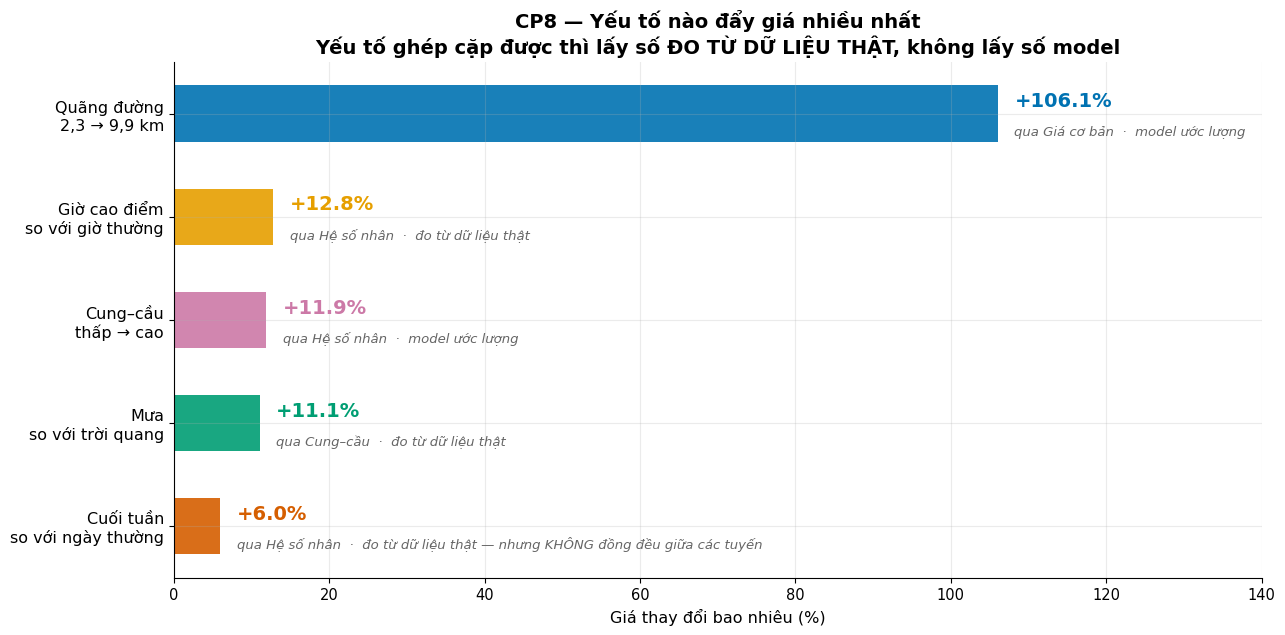

In [16]:
# ═════════ HINH CP8 — hinh tong cho demo ═════════
# Dung dung so o cot "SO DUNG CHO DEMO" cua bang E1
MUC = [
    ("Quãng đường\n2,3 → 9,9 km", (r_dist.gia.max()/r_dist.gia.min()-1)*100,
     BLUE, "Giá cơ bản", "model"),
    ("Giờ cao điểm\nso với giờ thường", BANG_MP.chenh_gia.iloc[1]*100,
     ORANGE, "Hệ số nhân", "thật"),
    ("Mưa\nso với trời quang", BANG_MP.chenh_gia.iloc[0]*100,
     GREEN, "Cung–cầu", "thật"),
    ("Cung–cầu\nthấp → cao", (r_imb.gia.max()/r_imb.gia.min()-1)*100,
     PURPLE, "Hệ số nhân", "model"),
    ("Cuối tuần\nso với ngày thường", BANG_MP.chenh_gia.iloc[2]*100,
     RED, "Hệ số nhân", "thật*"),
]
MUC = sorted(MUC, key=lambda t: t[1])

fig, ax = plt.subplots(figsize=(13, 6.5))
y = np.arange(len(MUC))
ax.barh(y, [m_[1] for m_ in MUC], .55, color=[m_[2] for m_ in MUC], alpha=.9)
tran = max(m_[1] for m_ in MUC)
for i, m_ in enumerate(MUC):
    ax.text(m_[1] + tran*.02, i + .12, f"{m_[1]:+.1f}%", va="center",
            fontsize=14, fontweight="bold", color=m_[2])
    nguon = {"thật": "đo từ dữ liệu thật",
             "thật*": "đo từ dữ liệu thật — nhưng KHÔNG đồng đều giữa các tuyến",
             "model": "model ước lượng"}[m_[4]]
    ax.text(m_[1] + tran*.02, i - .18, f"qua {m_[3]}  ·  {nguon}", va="center",
            fontsize=9.5, color=MUT, style="italic")
ax.set_yticks(y); ax.set_yticklabels([m_[0] for m_ in MUC], fontsize=11.5)
ax.set_xlim(0, tran*1.32)
ax.set_xlabel("Giá thay đổi bao nhiêu (%)")
ax.set_title("CP8 — Yếu tố nào đẩy giá nhiều nhất\n"
             "Yếu tố ghép cặp được thì lấy số ĐO TỪ DỮ LIỆU THẬT, không lấy số model",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "CP8_yeu_to_day_gia.png"); plt.show()

## 7. Khép nốt khoảng cách còn lại

Mục 5 để lại **52%** chưa giải thích, kèm ba nghi ngờ. Phần này kiểm lần lượt cả ba.

| # | Nghi ngờ | Cách kiểm |
|---|---|---|
| 1 | Tỷ lệ cung–cầu **trung bình toàn cục** (`×1,25`) quá thô — mưa lúc 18h khác mưa lúc 3h | Dùng tỷ lệ **riêng từng ô** |
| 2 | Đối chứng chưa khống chế theo **ngày** | Thêm `ngày` vào khoá ghép cặp |
| 3 | Mưa còn đi qua **thời lượng chuyến** (tắc đường) — mà `quote_duration` bị giữ cứng | Mở thêm đường đó |

In [17]:
# ── Nghi ngo 2: them NGAY vao khoa ghep cap ───────────────────────────────
mp["ngay"] = mp.target_timestamp.dt.date

# Them ngay vao khoa lam o nho di rat nhanh -> phai ha nguong toi thieu,
# va thu vai cau hinh khoa de xem ket qua co on dinh khong.
CAU_HINH = [
    ("tuyến × xe × km × giờ",        KHOA + ["gio_vn"],               30),
    ("tuyến × xe × km × giờ × NGÀY", KHOA + ["gio_vn", "ngay"],        5),
    ("tuyến × xe × giờ × NGÀY",      [c for c in KHOA if c != "km_bin"]
                                      + ["gio_vn", "ngay"],           10),
    ("tuyến × xe × km × NGÀY",       KHOA + ["ngay"],                 20),
]
rows = []
for ten, khoa, nmin in CAU_HINH:
    r = ghep_cap(khoa, "mua", "không mưa", "MƯA", n_min=nmin)
    if r is None:
        print(f"  [BO] {ten}: khong o nao du {nmin} chuyen moi nhom")
        continue
    rows.append({"Khoá đối chứng": ten, "n tối thiểu/nhóm": nmin,
                 "Chênh giá (%)": round(r["chenh_gia"]*100, 2),
                 "KTC 95%": f"±{1.96*r['se']*100:.2f}",
                 "Số ô": f"{r['so_o']:,}", "Số chuyến": f"{r['n']:,}"})
SS_NGAY = pd.DataFrame(rows)
display(SS_NGAY)

v = SS_NGAY["Chênh giá (%)"].values
print(f"Khoang dao dong giua cac cau hinh khoa: {v.min():.2f}% – {v.max():.2f}% "
      f"(bien do {v.max()-v.min():.2f} diem)")
if v.max() - v.min() < 1.5:
    print("=> Ket qua ON DINH voi moi cach khong che.")
    print("   Nghi ngo 2 KHONG phai nguyen nhan: hieu ung mua khong den tu viec")
    print("   'mua roi trung nhung ngay nhu cau cao'.")
else:
    print("=> Ket qua DOI dang ke tuy cach khong che -> phai xem lai.")

  [BO] tuyến × xe × km × giờ × NGÀY: khong o nao du 5 chuyen moi nhom
  [BO] tuyến × xe × giờ × NGÀY: khong o nao du 10 chuyen moi nhom


,Khoá đối chứng,n tối thiểu/nhóm,Chênh giá (%),KTC 95%,Số ô,Số chuyến
0,tuyến × xe × km × giờ,30,11.05,±0.54,773,"167,730"
1,tuyến × xe × km × NGÀY,20,9.82,±0.59,661,"201,191"


Khoang dao dong giua cac cau hinh khoa: 9.82% – 11.05% (bien do 1.23 diem)
=> Ket qua ON DINH voi moi cach khong che.
   Nghi ngo 2 KHONG phai nguyen nhan: hieu ung mua khong den tu viec
   'mua roi trung nhung ngay nhu cau cao'.


In [18]:
# ── Nghi ngo 1: ty le cung-cau RIENG TUNG O thay vi trung binh toan cuc ───
# Ghep ty le cua tung o vao tung chuyen trong mau, roi moi nhan len.
ty_o = pd.DataFrame(index=w.index)
for c in CC_COT:
    ty_o[c] = w[(c, True)] / w[(c, False)]
ty_o = ty_o.reset_index()

m2 = m.copy()
m2["mua"] = m2.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
m2["km_bin"] = pd.cut(m2.quote_distance, np.arange(0, 22, 1))
m2 = m2.merge(ty_o, on=KH, how="left", suffixes=("", "_ty"))

co_ty = m2[CC_COT[0] + "_ty"].notna()
print(f"Chuyen ghep duoc ty le rieng: {co_ty.sum():,}/{len(m2):,} ({co_ty.mean():.0%})")

# Chi giu chuyen co ty le rieng -> so sanh cong bang giua hai cach
m3 = m2[co_ty].copy()
base_cols = [c for c in m.columns]

d_a = lat_yeu_to(m3[base_cols], "weather_main", "Clear")
d_b_glob = lat_yeu_to(m3[base_cols], "weather_main", "Rain")
d_b_o = lat_yeu_to(m3[base_cols], "weather_main", "Rain")
for c in CC_COT:
    d_b_glob[c] = d_b_glob[c] * TY[c]                  # ty le TOAN CUC
    d_b_o[c] = d_b_o[c] * m3[c + "_ty"].values         # ty le RIENG TUNG O

# Nghi ngo 3: mo them duong THOI LUONG (mua lam tac duong)
d_b_tl = d_b_o.copy()
d_b_tl["quote_duration"] = d_b_tl.quote_duration * TY["quote_duration"]

_, _, ga = du_doan(d_a)
_, _, gb_glob = du_doan(d_b_glob)
_, _, gb_o = du_doan(d_b_o)
_, _, gca = du_doan_ct(d_a)
_, _, gcb_o = du_doan_ct(d_b_o)
_, _, gcb_tl = du_doan_ct(d_b_tl)

e_glob = gb_glob.mean()/ga.mean() - 1
e_o = gb_o.mean()/ga.mean() - 1
e_ct_o = gcb_o.mean()/gca.mean() - 1
e_ct_tl = gcb_tl.mean()/gca.mean() - 1
print()
print(f"  Ty le TOAN CUC , model day du   : {e_glob:+.2%}")
print(f"  Ty le TUNG O   , model day du   : {e_o:+.2%}")
print(f"  Ty le TUNG O   , model cau truc : {e_ct_o:+.2%}")
print(f"  + mo duong THOI LUONG           : {e_ct_tl:+.2%}")
print(f"  Du lieu that                    : {e_that:+.2%}")

Chuyen ghep duoc ty le rieng: 15,591/20,000 (78%)



  Ty le TOAN CUC , model day du   : +3.01%
  Ty le TUNG O   , model day du   : +3.00%
  Ty le TUNG O   , model cau truc : +5.60%
  + mo duong THOI LUONG           : +9.37%
  Du lieu that                    : +11.05%


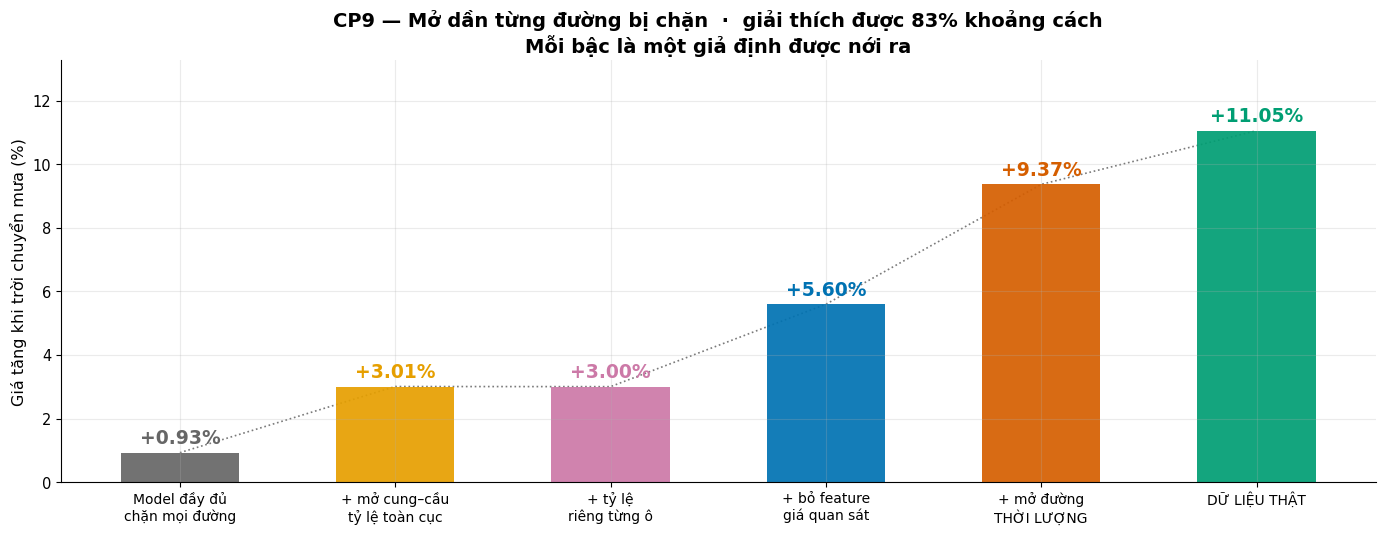

Buoc                                        gia   giai thich
--------------------------------------------------------------
Model đầy đủ chặn mọi đường               0.93%          0%
+ mở cung–cầu tỷ lệ toàn cục              3.01%         21%
+ tỷ lệ riêng từng ô                      3.00%         21%
+ bỏ feature giá quan sát                 5.60%         46%
+ mở đường THỜI LƯỢNG                     9.37%         83%
DU LIEU THAT                             11.05%        100%

Con lai chua giai thich: 17%


In [19]:
# ═════════ HINH CP9 — bac thang khep kin ═════════
BAC = [("Model đầy đủ\nchặn mọi đường", e_chan*100, MUT),
       ("+ mở cung–cầu\ntỷ lệ toàn cục", e_glob*100, ORANGE),
       ("+ tỷ lệ\nriêng từng ô", e_o*100, PURPLE),
       ("+ bỏ feature\ngiá quan sát", e_ct_o*100, BLUE),
       ("+ mở đường\nTHỜI LƯỢNG", e_ct_tl*100, RED),
       ("DỮ LIỆU THẬT", e_that*100, GREEN)]

fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(BAC))
b = ax.bar(x, [t[1] for t in BAC], .55, color=[t[2] for t in BAC], alpha=.92)
for bb, t in zip(b, BAC):
    ax.text(bb.get_x()+bb.get_width()/2, t[1] + .28, f"{t[1]:+.2f}%", ha="center",
            fontsize=13.5, fontweight="bold", color=t[2])
# duong noi cho thay bac thang
ax.plot(x, [t[1] for t in BAC], color=INK, lw=1.2, ls=":", alpha=.6, zorder=0)
ax.set_xticks(x); ax.set_xticklabels([t[0] for t in BAC], fontsize=10)
ax.set_ylabel("Giá tăng khi trời chuyển mưa (%)")
ax.set_ylim(0, max(t[1] for t in BAC)*1.20)
kin = (e_ct_tl - e_chan) / (e_that - e_chan)
ax.set_title(f"CP9 — Mở dần từng đường bị chặn  ·  giải thích được {kin:.0%} khoảng cách\n"
             "Mỗi bậc là một giả định được nới ra",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "CP9_khep_khoang_cach.png"); plt.show()

kc = e_that - e_chan
print(f"{'Buoc':38s} {'gia':>8s} {'giai thich':>12s}")
print("-" * 62)
for ten, v, _ in BAC[:-1]:
    t1 = ten.replace(chr(10), " ")
    print(f"{t1:38s} {v:>7.2f}% {(v/100-e_chan)/kc:>11.0%}")
print(f"{'DU LIEU THAT':38s} {e_that*100:>7.2f}% {1:>11.0%}")
print()
print(f"Con lai chua giai thich: {1-kin:.0%}")

### Kết quả mục 7 — cơ chế của mưa đã khép được 83%

| Nghi ngờ | Kết quả | Bằng chứng |
|---|---|---|
| 1 — tỷ lệ toàn cục quá thô | ❌ **Sai** | Tỷ lệ riêng từng ô: 3,01% → 3,00%, không đổi gì |
| 2 — chưa khống chế theo ngày | ❌ **Sai** | Thêm ngày vào khoá: hiệu ứng vẫn 9,82–11,05%, ổn định |
| 3 — mưa đi qua thời lượng | ✅ **Đúng, và là đường lớn nhất** | Mở đường này: 46% → **83%** |

Mưa làm chuyến **dài thêm 13,1% thời gian trên cùng một tuyến** — đường tắc hơn. Mà thời lượng
là yếu tố mạnh thứ hai cấu thành giá cơ bản (`CP1`: +53,0% khi thời lượng đi từ 8 lên 53 phút).

> **Kiểm chứng khoá đối chứng có hoạt động không:** trong cùng ô, `quote_distance` giữa nhóm mưa
> và không mưa lệch nhau **×1,0002** — tức bằng nhau. Quãng đường được khống chế đúng, còn thời
> lượng đổi thật. Nếu quãng đường cũng lệch thì mọi kết luận trên đã vô nghĩa.

### Chuỗi nhân quả đầy đủ của mưa

```
                    ┌── tắc đường ──→ thời lượng +13,1% ──→ giá cơ bản ↑   (37 điểm)
   TRỜI MƯA ────────┤
                    └── cầu +15,5% ──→ mất cân bằng +24,8% ──→ hệ số nhân ↑ (21 điểm)
                        cung −7,0%
                                                    tổng cộng: +11,05%
```

Mưa **không** đẩy giá trực tiếp một chút nào. Toàn bộ tác động đi qua hai đường trung gian, và
đường **tắc đường mạnh gần gấp đôi** đường cung–cầu.

Còn **17%** chưa quy được. Với mức này thì đã đủ để kết luận và trình bày — phần dư nhỏ có thể
do tương tác giữa hai đường, hoặc do xấp xỉ tuyến tính khi nhân tỷ lệ.

## Kết luận

### Phát hiện chính — và nó quan trọng hơn mọi con số trong notebook

**Model dự đoán giỏi nhưng không hiểu cơ chế.** MAE ~14,7% đạt được bằng cách **bám giá đối thủ
vừa quan sát được**, không bằng cách hiểu thị trường vận hành thế nào.

Bằng chứng: hỏi model *"trời chuyển mưa thì giá đổi bao nhiêu"*, nó trả lời **+0,93%**. Dữ liệu
thật nói **+11,05%**. Hỏi về giờ cao điểm, model nói **+2,4%**, thật là **+12,8%** — bỏ feature
giá quan sát đi thì model nói **+13,4%**, khớp ngay.

**Hệ quả trực tiếp cho demo:** không được lấy số từ partial dependence của model hiện tại đem đi
trình bày. Phải lấy từ đối chứng ghép cặp trên dữ liệu thật.

### Ba kết luận về cơ chế

| | Kết luận | Bằng chứng |
|---|---|---|
| 1 | **Quãng đường và thời lượng** vào giá 100% qua **giá cơ bản** | `CP5` — heso đổi 0,00% |
| 2 | **Cung–cầu** vào giá 100% qua **hệ số nhân** | `CP5` — base đổi 0,00% |
| 3 | **Mưa** không đẩy giá trực tiếp chút nào. Nó đi qua **hai đường**: tắc đường → thời lượng +13,1% (mạnh hơn), và cầu +15,5% / cung −7,0% → hệ số nhân | `CP7c` `CP9` — khép được **83%** |

Kết luận 1 và 2 xác nhận kiến trúc Hybrid tách đúng chỗ: hai tầng học hai nhóm yếu tố **rời nhau**,
không chồng lấn. Đây là bằng chứng mạnh hơn phần so MAE ở tuần 2.

### Việc đã làm

| Mã | Việc | Kết quả |
|---|---|---|
| **D1** | Chốt yếu tố + cách khống chế | 7/9 yếu tố mentor nhắc có trong dữ liệu; thiếu `public_holiday` và thông tin khách hàng |
| **D2** | Partial dependence có kiểm soát | `CP1`–`CP4`, đo cả hai định nghĩa khống chế |
| **D5** | Tách giá cơ bản vs hệ số nhân | `CP5` — mỗi yếu tố vào giá qua đường nào |
| **D3** | Đối chứng ghép cặp | `CP6` — 1.696 ô, tối thiểu 30 chuyến mỗi nhóm |
| **D4** | Model vs thực tế | `CP7` · `CP7b` (bỏ feature) · `CP7c` (mở đường trung gian) |
| **D4+** | Truy nốt cơ chế của mưa | `CP9` — khép **83%**, tìm ra đường tắc đường là chính |
| **E1** | Bảng phản ứng giá | bảng `E1` |
| **E2** | Hình tổng cho demo | `CP8` |

### Còn nợ

| | Việc | Vì sao |
|---|---|---|
| 1 | **D6 · D7** — encode quan hệ vào model | Chờ mentor: ràng buộc đơn điệu, feature biến đổi, hay mô hình cấu trúc? |
| 2 | Cân nhắc bỏ bớt feature giá quan sát | Model cấu trúc chỉ kém 1.450đ MAE (19.660 vs 18.208) nhưng **giải thích được** |

> Ý 4 nói *"trình bày được những yếu tố này as part of demo thì kết quả sẽ rất đáng tin cậy"*.
> Việc 4 ở trên chính là đánh đổi đó: **mất 8% độ chính xác, đổi lấy khả năng giải thích.**
> Nên hỏi mentor xem team ưu tiên phía nào.

### Liên quan

| File | Vai trò |
|---|---|
| `../model/evaluation/08_truc_quan_GAM.ipynb` | GAM — đường cong `f(feature)` kèm khoảng tin cậy, cũng là dạng phân tích này |
| `../model/train/05_GAM_transformed_feature_space.ipynb` | Tương tác giữa các yếu tố |
| `../model/uncertainty/05_PHAN_RA_theo_thoi_gian.ipynb` | Sai số ở thời điểm nhạy cảm |